# **Credit Card Fraud Detection - 2201404**

## **Importing all the required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn import metrics
from collections import Counter
from scipy import stats
import statsmodels.api as sm
from scipy.stats import skew, stats, shapiro, spearmanr, norm
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from tabulate import tabulate
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import PowerTransformer # Import log transformer

### **Importing the dataset from Kaggle**

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

 97% 64.0M/66.0M [00:00<00:00, 150MB/s]
100% 66.0M/66.0M [00:00<00:00, 137MB/s]
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


> **Note**
*   The dataset is imported from [Kaggle website](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).
*   To access and import dataset from Kaggle, a json file must be downloaded and loaded into google colab Files.
*   Steps to download the kaggle.json file:    
Sign In / Register -> Settings -> API -> Create New Token -> download.

If the above is not possible download the dataset from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and upload it to GDrive.

### **Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Accessing CSV Dataset file from GDrive**

In [ ]:
# Load the CSV dataset from your Google Drive
file_path = '/content/drive/MyDrive/Dissertation/Dataset/creditcard.csv'
data = pd.read_csv(file_path)

In [ ]:
data = pd.read_csv('creditcard.csv')
data.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## **Understanding the imported dataset**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Observation**


*   The dataset has 284806 rows and 31 columns.
*   All the columns are numeric data type.
*   Therefore there is no need for encoding / tranformation of data.

### **Summary Statistics of the dataset**

In [ ]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
data.shape

(284807, 31)

## **Exploratory Data Analysis (EDA)**

### **Handling Null/ Missing values in the dataset**

In [ ]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

**Observation**
*   As there is no Null / Missing values in the dataset, There is no need for any imputation methods (Mean/Median/Mode Imputation or Forward Fill (or Backward Fill) Imputation or Interpolation or etc.,) to be implemented.

### **Handling Data duplicates**

In [ ]:
data.duplicated().sum()

1081

In [ ]:
data.drop_duplicates(inplace=True)
print("Duplicated values dropped succesfully")

Duplicated values dropped succesfully


**Interpretation**:
*   Removing duplicate data (1081) from the dataset, which comprises 284806 rows and 31 columns, does not cause data loss.

### **Handling outliers**

The main reason not to drop outliers from our dataset is shown in the upcoming steps.

In [ ]:
data["Class"].value_counts()

0    283253
1       473
Name: Class, dtype: int64

> **Note**
*   0-> Non-Fraud transactions
*   1-> Fraud tranactions


In [ ]:
df=data.copy()

In [ ]:
num_col = (list(df.loc[:, 'V1':'Amount']))

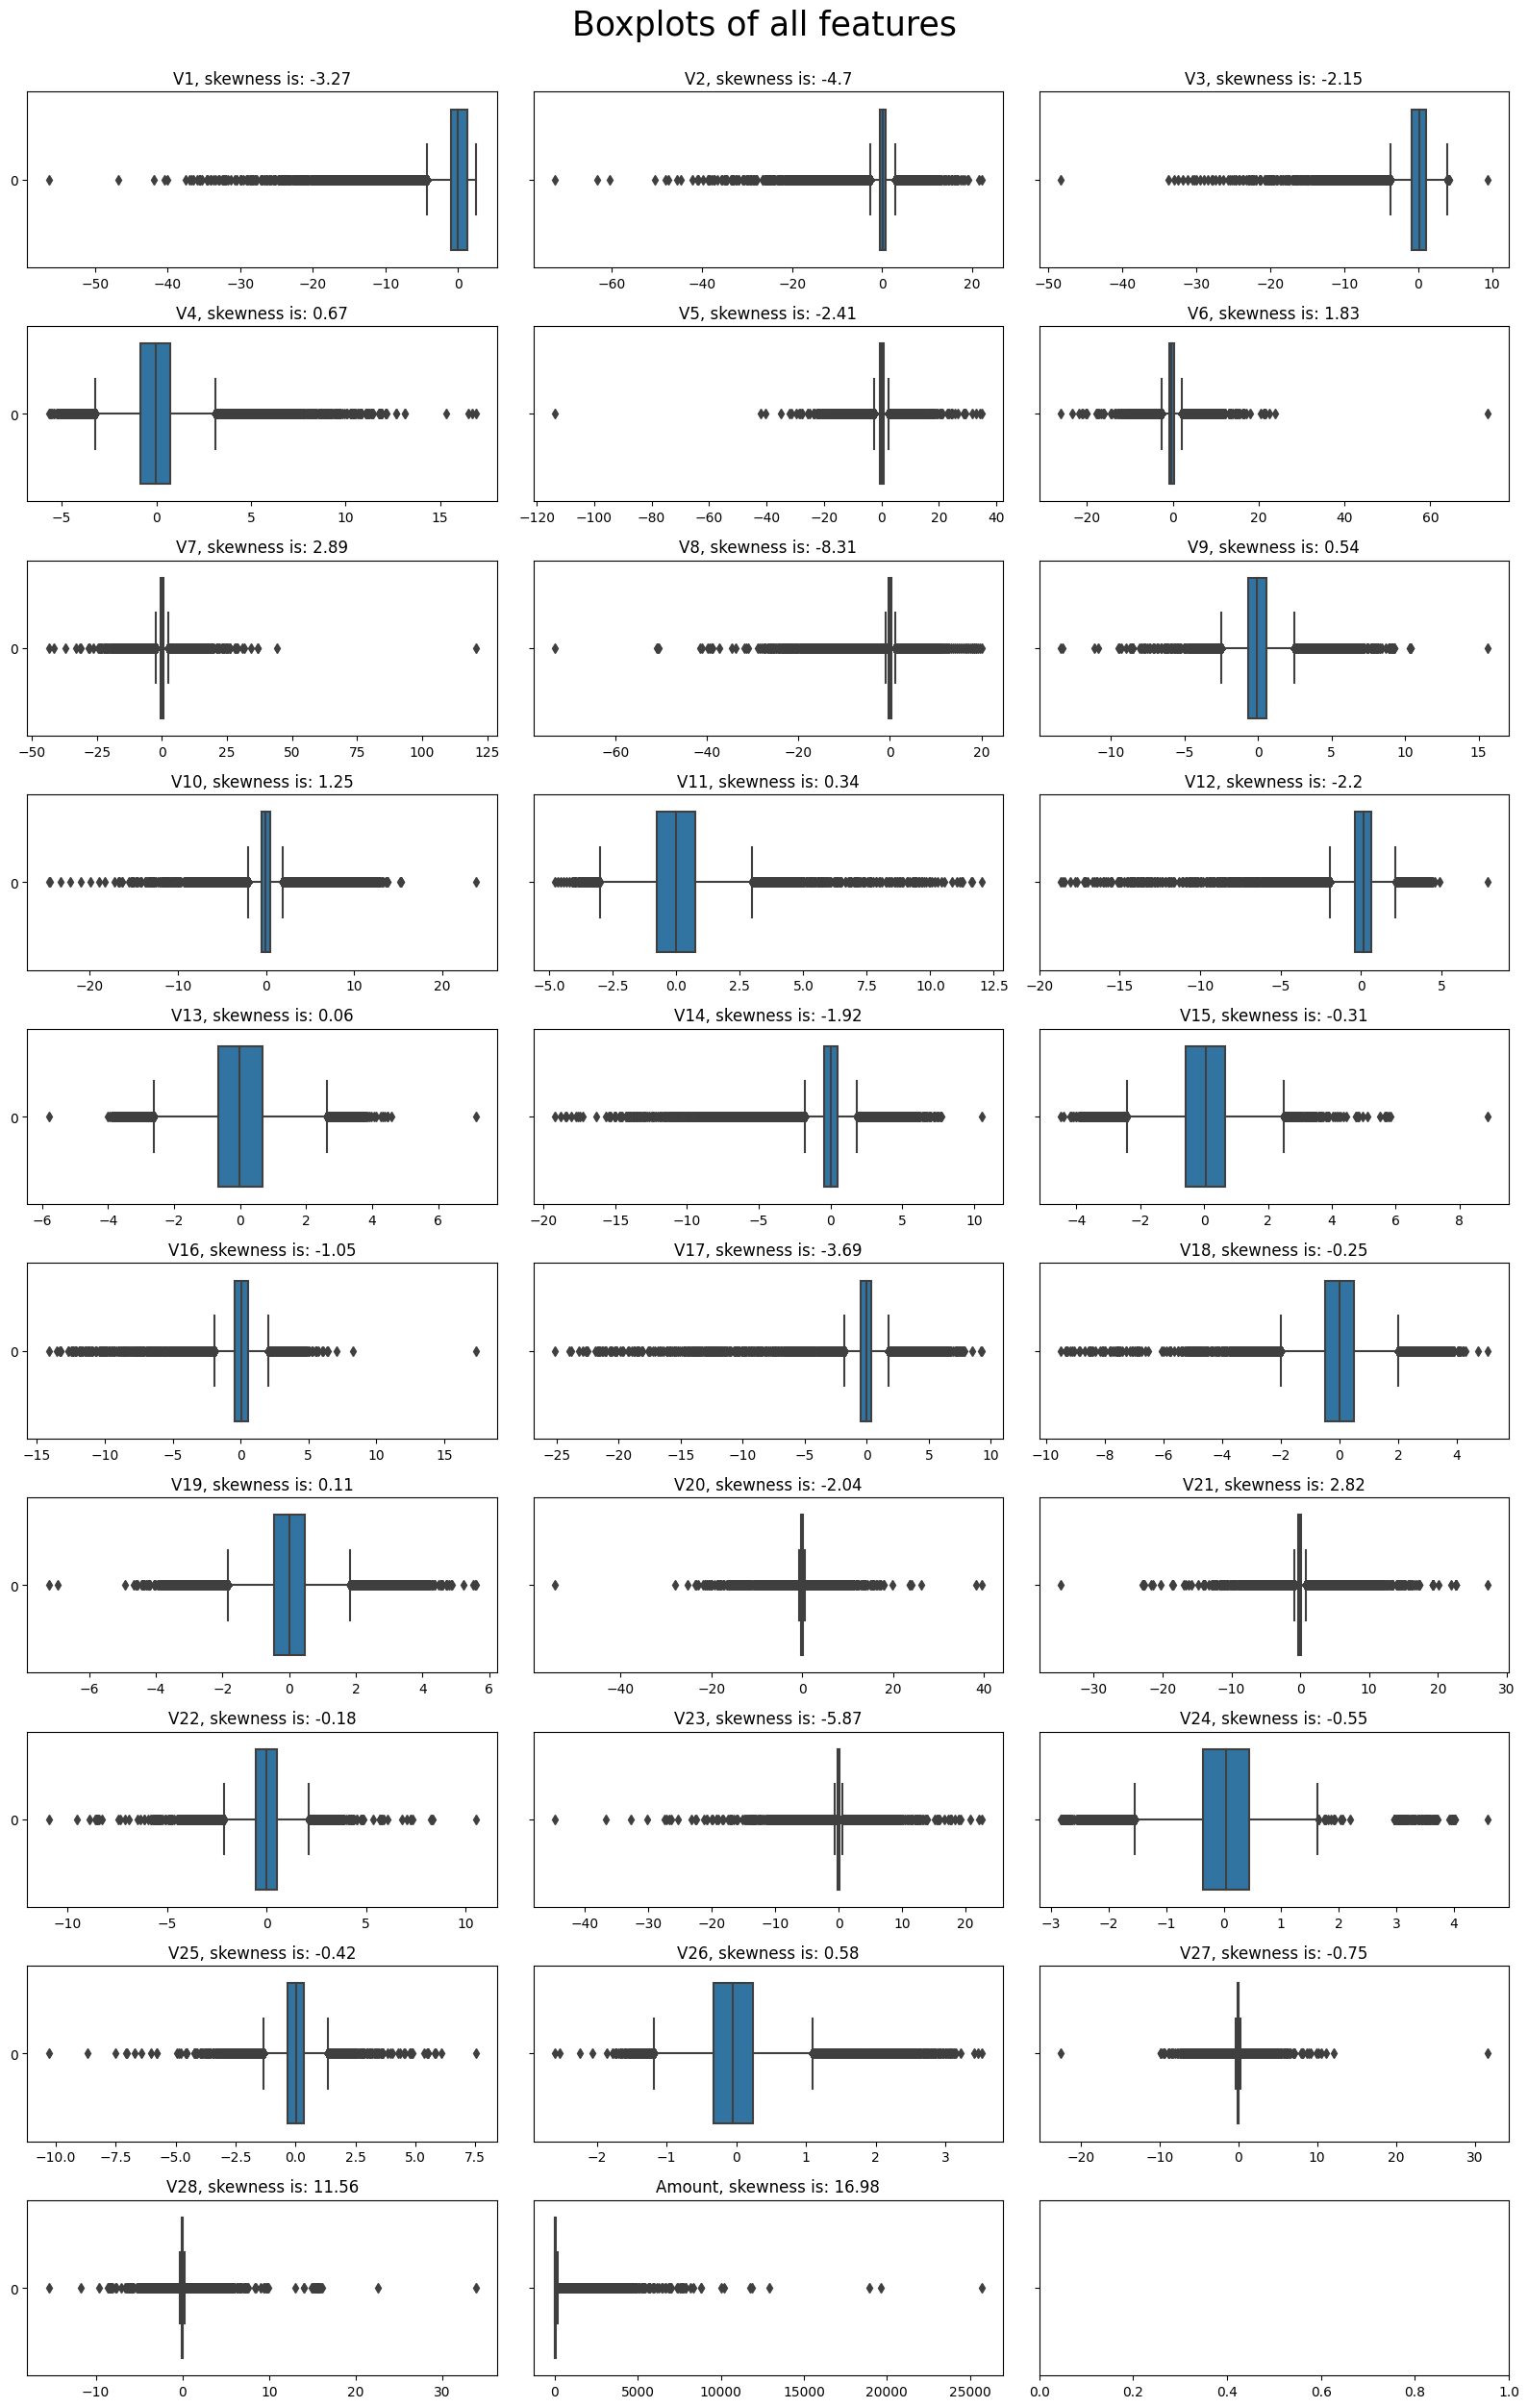

In [ ]:
# checking boxplots
def boxplots(dataset, col_list, rows, cols, subtitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,25))
    fig.suptitle(subtitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(col_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))

boxplots(dataset=df, col_list=num_col, rows=10, cols=3, subtitle='Boxplots of all features')
plt.tight_layout()

*  To identify outliers in skewed or non-bell-shaped data, Tukey's (1977) technique is often used as it does not make any distributional assumptions. However, it may not be suitable for small sample sizes. As a general guideline, anything that falls outside of the range between (Q1 - 1.5 IQR) and (Q3 + 1.5 IQR) should be considered an outlier and removed.
*   The Inter Quartile Range (IQR) is a commonly used method for detecting and removing outliers.

In [ ]:
def method_IQR (df,n,features):
    """
    Takes a dataframe and returns an index list corresponding to the observations
    containing more than n outliers according to the Tukey IQR method.
    """
    outliers_list = []

    for column in features:
        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column],75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        # outlier step
        outlier_step = 1.5 * IQR
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        # appending the list of outliers
        outliers_list.extend(outlier_list_column)

    # selecting observations containing more than x outliers
    outliers_list = Counter(outliers_list)
    multiple_outliers = list( k for k, v in outliers_list.items() if v > n )

    # Calculate the number of records below and above lower and above bound value respectively
    out1 = df[df[column] < Q1 - outlier_step]
    out2 = df[df[column] > Q3 + outlier_step]

    print('Total number of deleted outliers is:', out1.shape[0]+out2.shape[0])

    return multiple_outliers

In [ ]:
# detecting outliers
Outliers_IQR = method_IQR(df,1,num_col)

# dropping outliers
df = df.drop(Outliers_IQR, axis = 0).reset_index(drop=True)

Total number of deleted outliers is: 31685


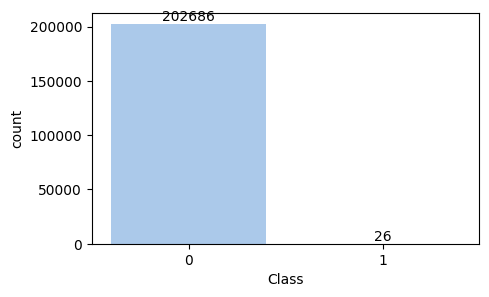

In [ ]:
plt.figure(figsize=(5,3))
ax = sns.countplot(x='Class',data=df,palette="pastel")
for i in ax.containers:
    ax.bar_label(i,)

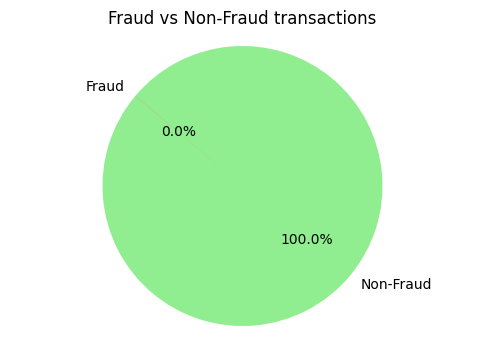

In [ ]:
labels = ["Non-Fraud", "Fraud"]
class_value_counts = df["Class"].value_counts().tolist()
values = [class_value_counts[0], class_value_counts[1]]
colors = ["lightgreen", "red"]

# Create the pie chart
plt.figure(figsize=(6, 4))
plt.pie(values, labels=labels, colors=colors, autopct="%1.1f%%", startangle=140)
plt.title("Fraud vs Non-Fraud transactions")
plt.axis("equal")  # Equal aspect ratio ensures the pie chart is circular.

# Show the chart
plt.show()

**Observation**
*   Intially the dataset had 492 (0.173%) fraud transactions and 284315 (99.8%) Non-Fraud transactions.
*   After removing outliers in the dataset, there are, 26 (0.0128%) Fraud transactions and 202686 (nearly 100%) Non-Fraud transactions in the entire dataframe.
*   We now face a huge dataloss problem and the imbalance in the data set increased even more making the problem much worse and unfit to fit into the model.
*   Therefore, It is better to not handle the outlier and keep the original data for further investigation.

### **Check for normality distribution**

**Shapiro-Wilk test**

In [ ]:
print("Feature\t\tStatistic\tp-value")
for feature in data.columns:
    stat, p = shapiro(data[feature])
    print(f"{feature}\t\t{stat:.5f}\t\t{p:.5f}")

Feature		Statistic	p-value
Time		0.94032		0.00000


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


V1		0.80037		0.00000
V2		0.73910		0.00000
V3		0.91198		0.00000
V4		0.96948		0.00000
V5		0.82528		0.00000
V6		0.84455		0.00000
V7		0.72986		0.00000
V8		0.50408		0.00000
V9		0.97104		0.00000
V10		0.82270		0.00000
V11		0.98609		0.00000
V12		0.88715		0.00000
V13		0.99901		0.00000
V14		0.88892		0.00000
V15		0.99360		0.00000
V16		0.95286		0.00000
V17		0.79740		0.00000
V18		0.98526		0.00000
V19		0.98304		0.00000
V20		0.52852		0.00000
V21		0.49454		0.00000
V22		0.98427		0.00000
V23		0.46755		0.00000
V24		0.97119		0.00000
V25		0.97506		0.00000
V26		0.97856		0.00000
V27		0.58642		0.00000
V28		0.43775		0.00000
Amount		0.31005		0.00000
Class		0.01735		0.00000


**Histogram of Dataset**

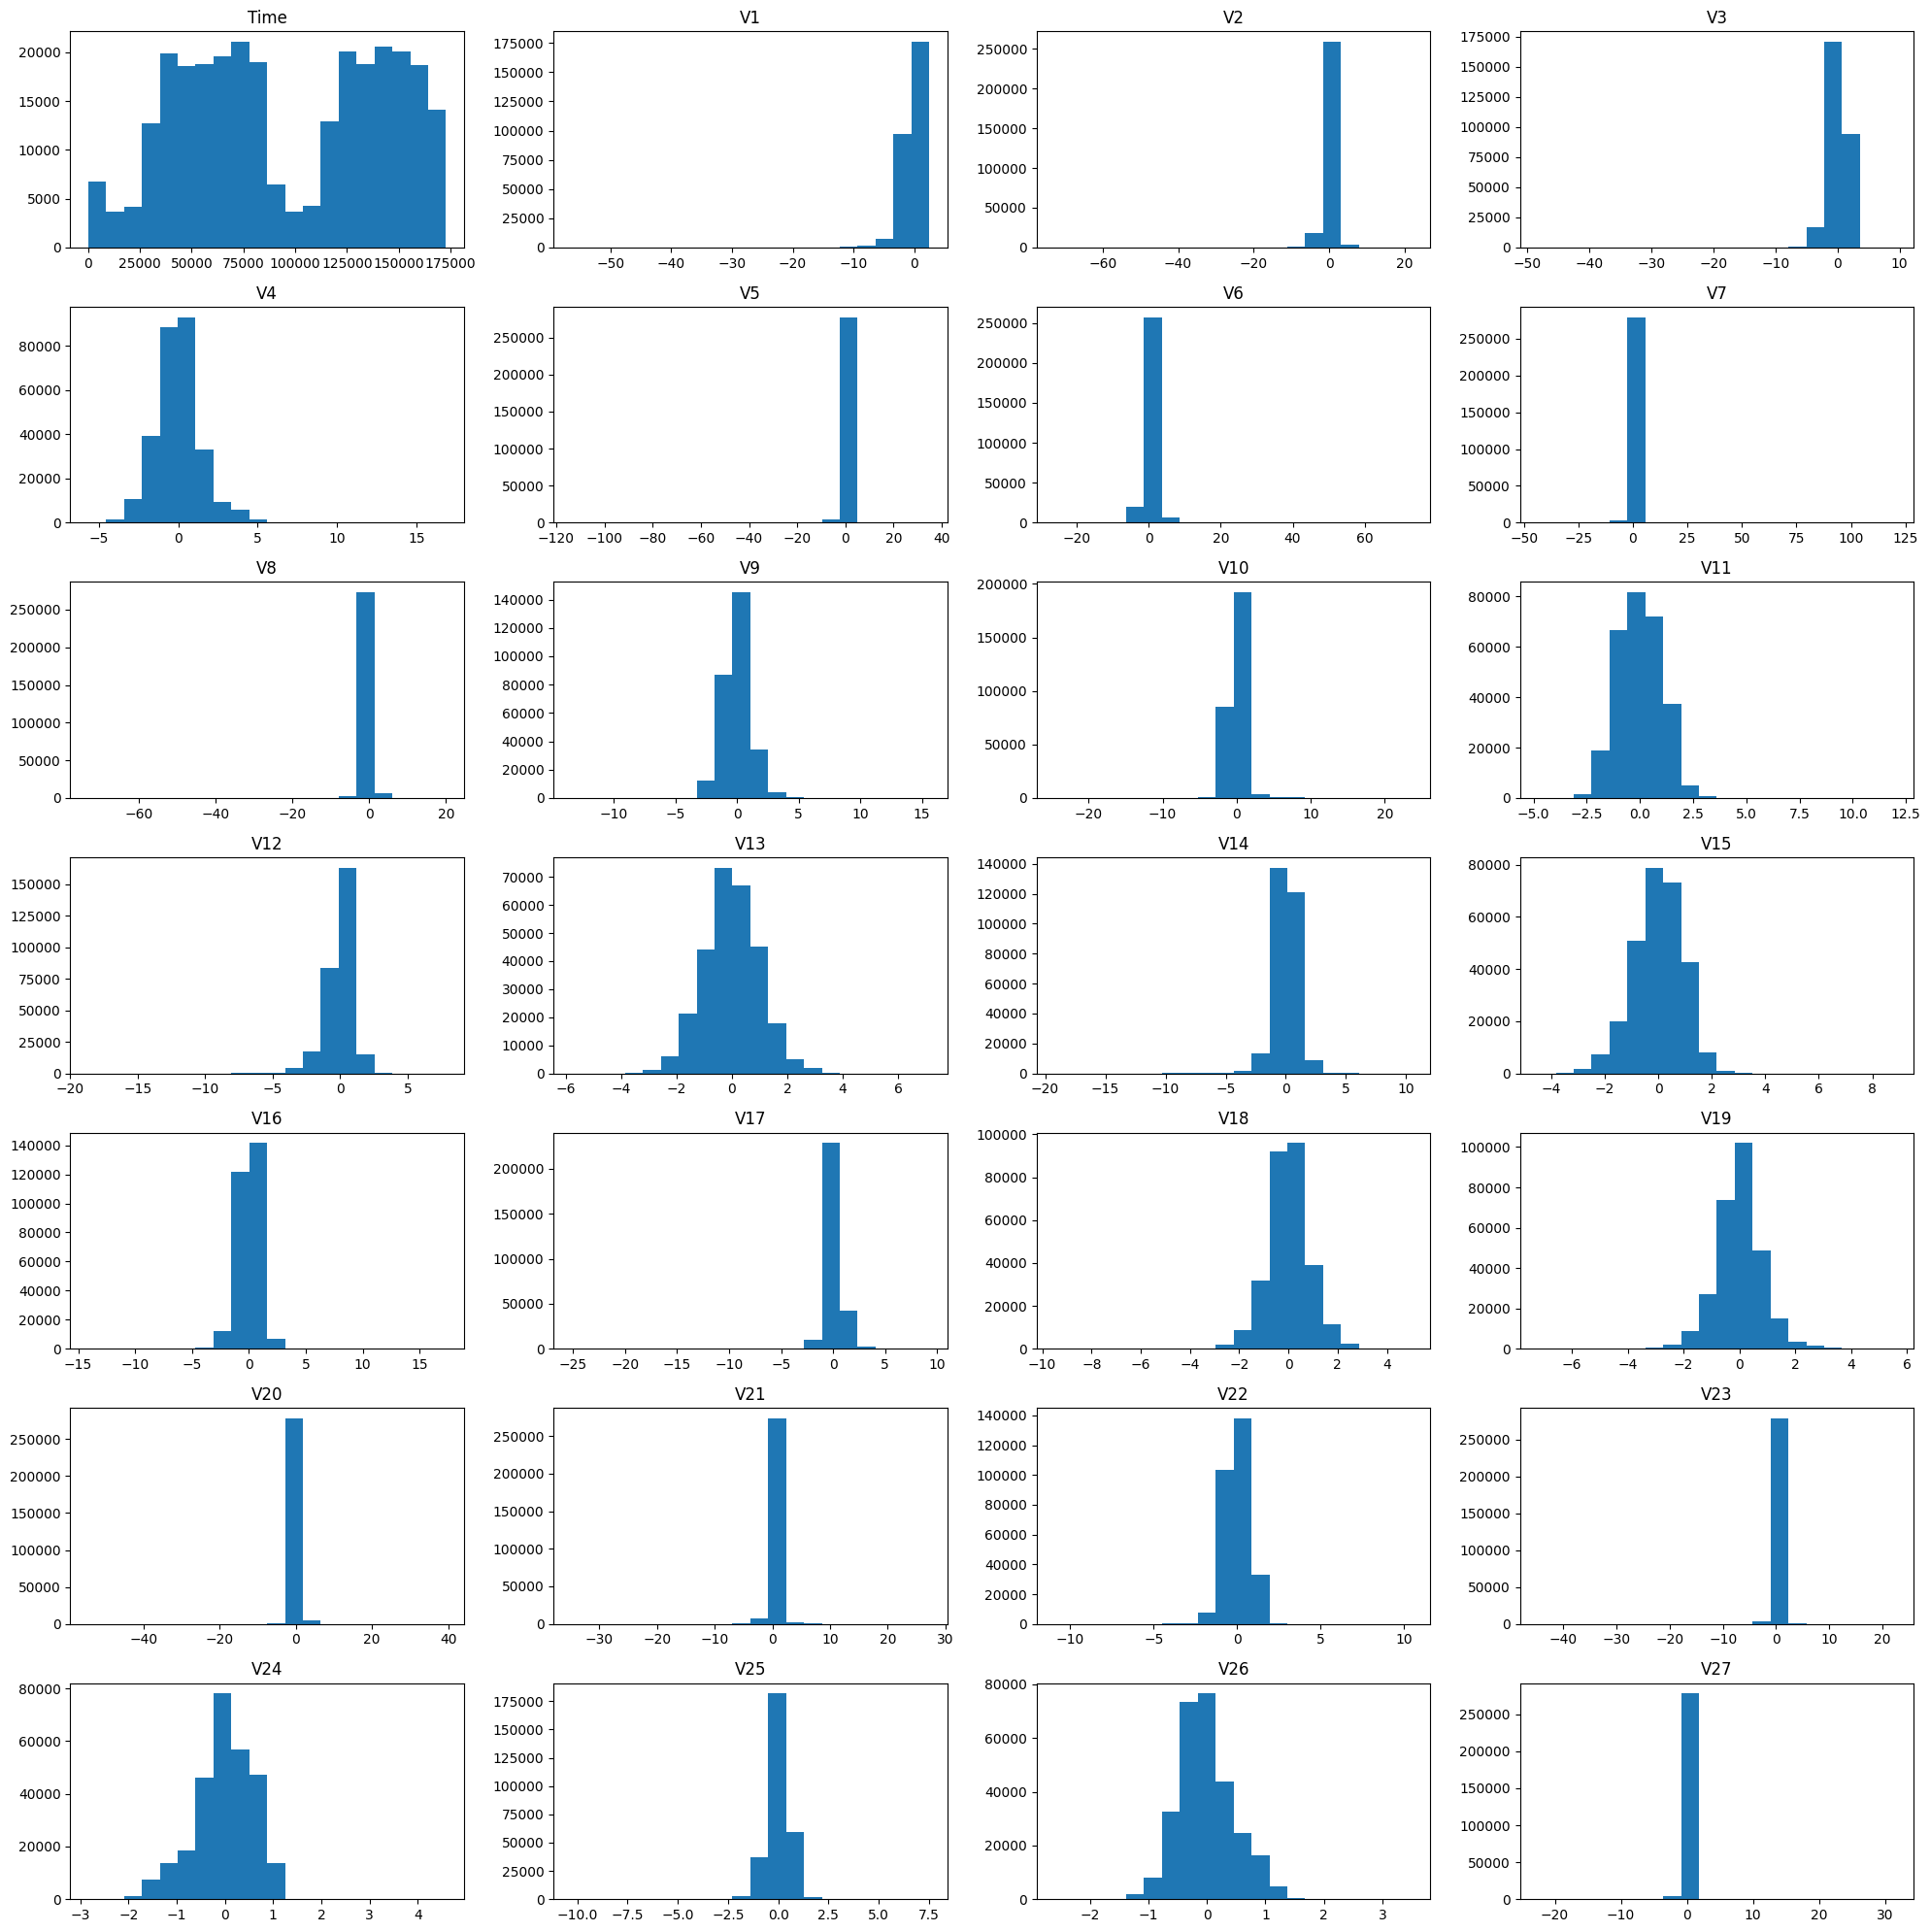

In [ ]:
# Histogram plots
fig, axes = plt.subplots(ncols=4, nrows=7, figsize=(20,20))

for i, ax in enumerate(axes.flatten()):
    if i < len(data.columns):
        ax.hist(data.iloc[:,i], bins=20)
        ax.set_title(data.columns[i])

fig.tight_layout()
plt.show()

**QQ Plot**

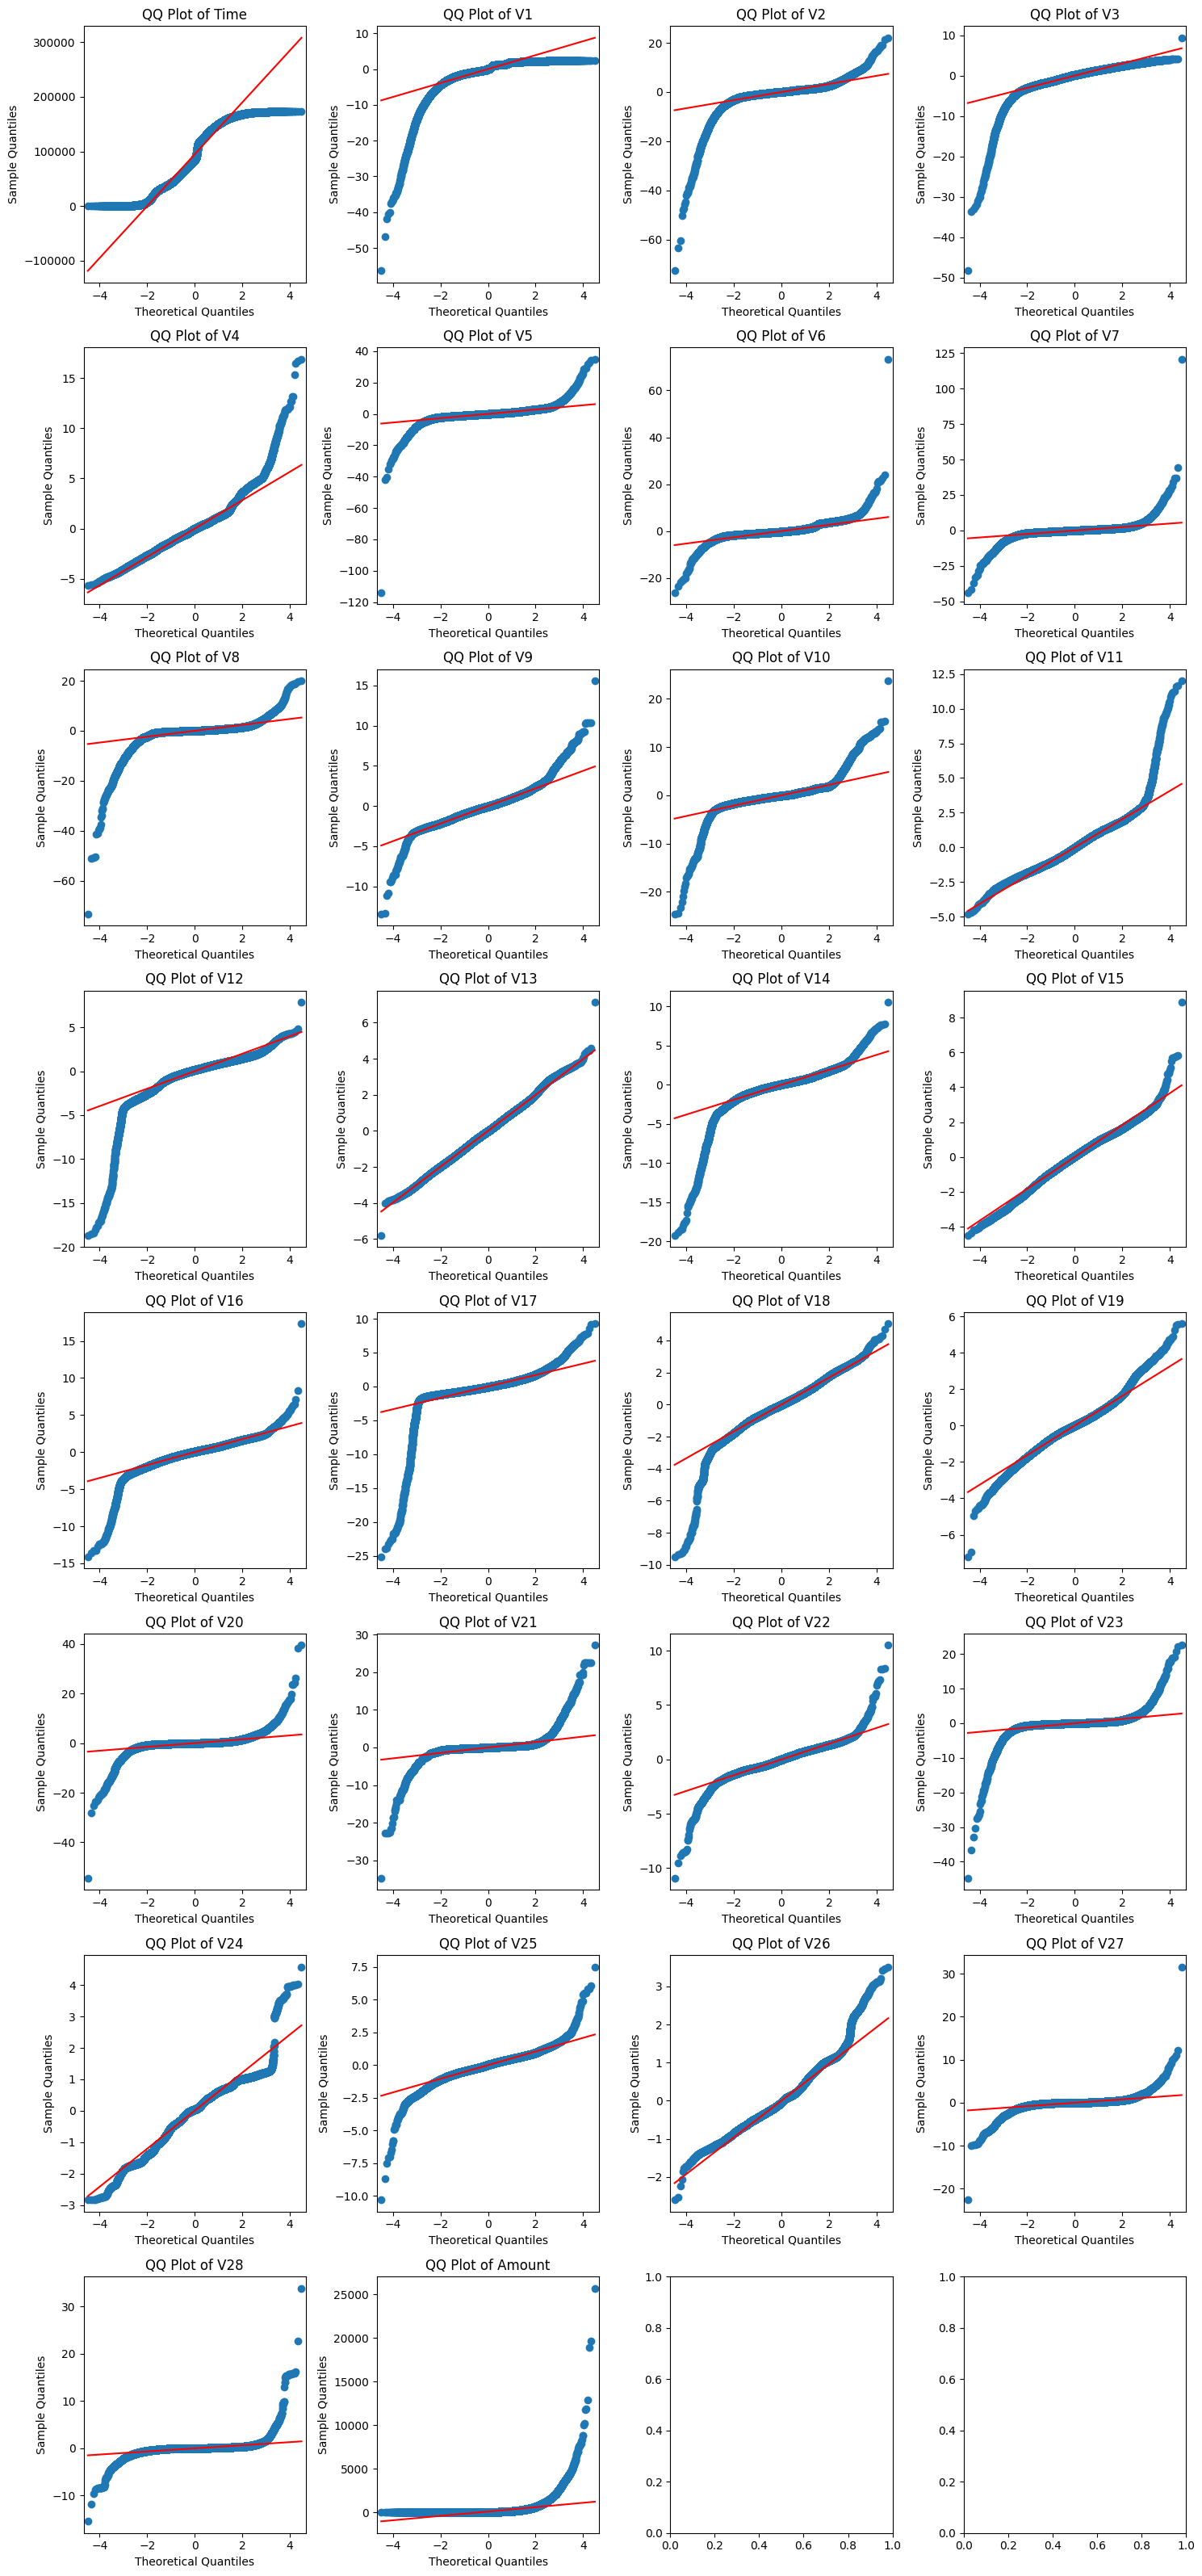

In [ ]:
# Get the list of features (excluding 'Class' column)
features = [col for col in data.columns if col != 'Class']

# Calculate the number of rows and columns for subplots
num_rows = (len(features) + 3) // 4  # Ceiling division
num_cols = min(4, len(features))

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))

# Loop through each feature and create QQ plots
for i, feature in enumerate(features):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]

    # Create QQ plot for the current feature
    sm.qqplot(data[feature], line='s', ax=ax)
    ax.set_title(f'QQ Plot of {feature}')

# Adjust layout and display plots
plt.tight_layout()
plt.show()

**Observation of test to check normality distibution**
*   The features - V4, V9, V11, V13, V15, V18, V19, V24, V26 are normally distributed.
*   Shapiro-Wilk test showed most features are not normally distributed with p-values < 0.05.
*   The histogram plots visualized the non-normal distributions - tilted, multi-modal, right-skewed.
*   The Q-Q plots also showed deviations from the normality trend line, further indicating non-normality.





## **Data Visualization**

Visualize the data to detect any anomalies and gain insights.

### **Histogram of Amount**

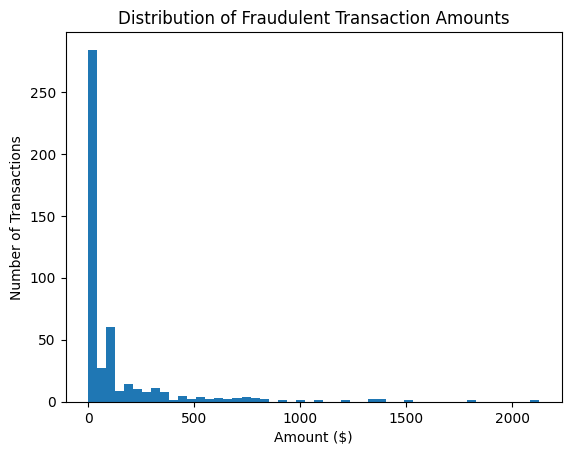

In [ ]:
# Filter only fraud class
fraud = data[data['Class'] == 1]

# Create histogram
plt.hist(fraud['Amount'], bins = 50)

plt.title('Distribution of Fraudulent Transaction Amounts')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')

plt.show()

**Observation**
*   Right skewed distribution, with most transactions being small amounts
*   Potential outliers with very large amounts.
*   Most fraudulent transactions are small amounts





### **Scatterplot of V1 vs V2 colored by Class**



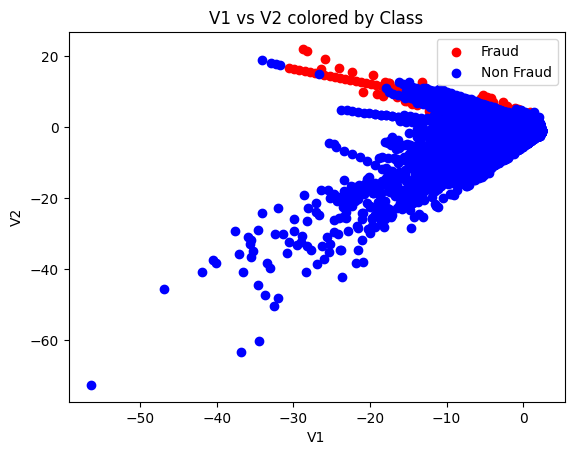

In [ ]:
# Create scatter plot
fraud = data[data['Class'] == 1]
non_fraud = data[data['Class'] == 0]

plt.scatter(fraud['V1'], fraud['V2'], color='r', label='Fraud')
plt.scatter(non_fraud['V1'], non_fraud['V2'], color='b', label='Non Fraud')

plt.xlabel('V1')
plt.ylabel('V2')
plt.legend()
plt.title('V1 vs V2 colored by Class')

plt.show()

**Observation**
*   The fraudulent (red) and non-fraudulent (blue) points are interleaved and don't form distinct clusters. This indicates V1 and V2 don't clearly separate the classes.
*   The fraudulent points appear generally distributed amongst rather than isolated from the non-fraudulent points. No strong boundaries are evident.
*   No obvious nonlinear patterns like rings or spirals are visible which might distinguish the classes. The relationship appears fairly linear.


### **Time Series Plot**

In [ ]:
# Separate the data into fraudulent and non-fraudulent transactions
fraud_data = data[data['Class'] == 1]
non_fraud_data = data[data['Class'] == 0]

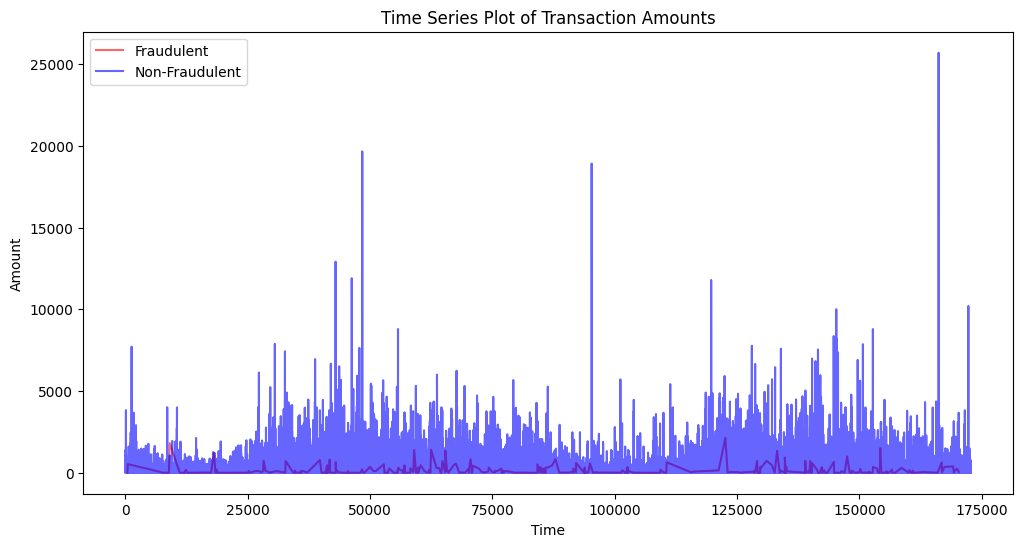

In [ ]:
# Create time series plots for fraudulent and non-fraudulent transactions
plt.figure(figsize=(12, 6))

plt.plot(fraud_data['Time'], fraud_data['Amount'], color='red', label='Fraudulent', alpha=0.6)
plt.plot(non_fraud_data['Time'], non_fraud_data['Amount'], color='blue', label='Non-Fraudulent', alpha=0.6)

plt.title('Time Series Plot of Transaction Amounts')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()
plt.show()


### **Time vs. Amount for Classes**

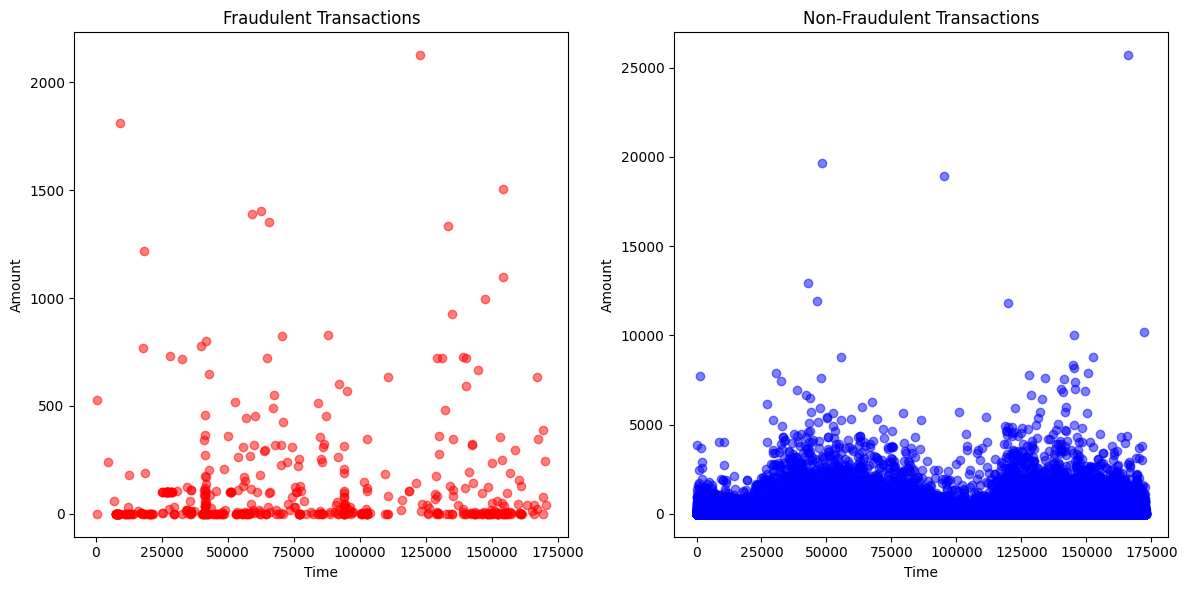

In [ ]:
# Create separate scatter plots for fraudulent and non-fraudulent transactions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(fraud_data['Time'], fraud_data['Amount'], color='red', alpha=0.5)
plt.title('Fraudulent Transactions')
plt.xlabel('Time')
plt.ylabel('Amount')

plt.subplot(1, 2, 2)
plt.scatter(non_fraud_data['Time'], non_fraud_data['Amount'], color='blue', alpha=0.5)
plt.title('Non-Fraudulent Transactions')
plt.xlabel('Time')
plt.ylabel('Amount')

plt.tight_layout()
plt.show()


**Observation**


> **Fraudulent Transactions**:
*   The scatter plot for fraudulent transactions (in red) shows a relatively uniform distribution of transaction amounts across different time periods.
*   There are no clear patterns or trends that distinguish fraudulent transactions based solely on the 'Time' and 'Amount' variables.


> **Non-Fraudulent Transactions**:
*   The scatter plot for non-fraudulent transactions (in blue) also shows a relatively uniform distribution of transaction amounts across different time periods.
*   there are no distinct patterns or trends based on 'Time' and 'Amount' that can effectively differentiate non-fraudulent transactions.









### **Distribution of classes with time**

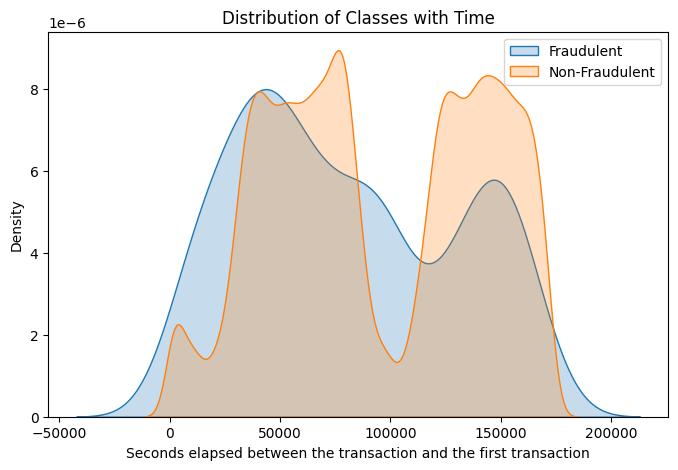

In [ ]:
# Distribution plot comparing fraudulent and non-fraudulent transactions over time
plt.figure(figsize=(8, 5))
sns.kdeplot(fraud_data['Time'], label='Fraudulent', fill=True)
sns.kdeplot(non_fraud_data['Time'], label='Non-Fraudulent', fill=True)
plt.xlabel('Seconds elapsed between the transaction and the first transaction')
plt.ylabel('Density')
plt.title('Distribution of Classes with Time')
plt.legend()
plt.show()


**Observation**
*   We do not see any specific pattern for the fraudulent and non-fraudulent transactions with respect to Time.



### **Distribution of classes with amount**

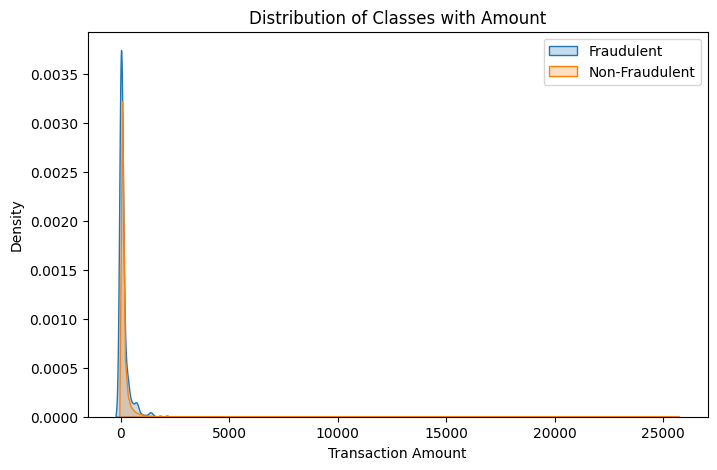

In [ ]:
# Distribution plot comparing fraudulent and non-fraudulent transactions over amount
plt.figure(figsize=(8, 5))
sns.kdeplot(fraud_data['Amount'], label='Fraudulent', fill=True)
sns.kdeplot(non_fraud_data['Amount'], label='Non-Fraudulent', fill=True)
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.title('Distribution of Classes with Amount')
plt.legend()
plt.show()



**Observation**
*   We can see that the fraud transctions are mostly densed in the lower range of amount, whereas the non-fraud transctions are spreaded throughout low to high range of amount.



### **Data Imbalance check**

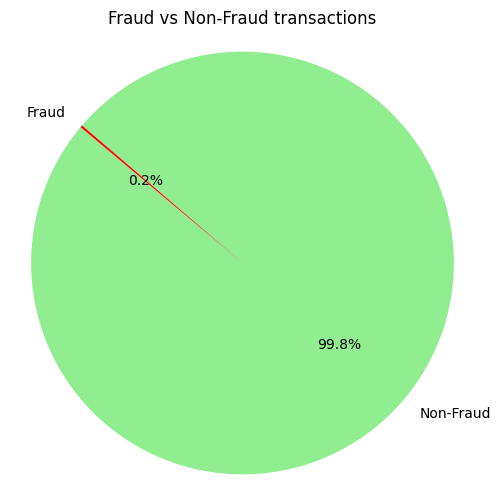

In [ ]:
# Data
labels = ["Non-Fraud", "Fraud"]
class_value_counts = data["Class"].value_counts().tolist()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(class_value_counts, labels=labels, colors=["lightgreen", "red"], autopct="%1.1f%%", startangle=140)
plt.title("Fraud vs Non-Fraud transactions")
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the chart
plt.show()

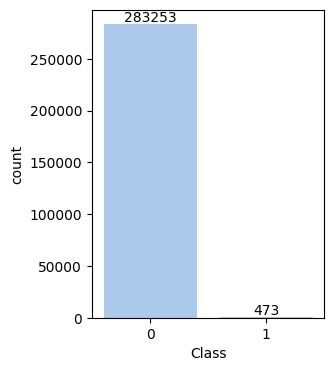

In [ ]:
plt.figure(figsize=(3,4))
ax = sns.countplot(x='Class',data=data,palette="pastel")
for i in ax.containers:
    ax.bar_label(i,)

In [ ]:
print('Non-Fraud:', round(data['Class'].value_counts()[0]/len(data) * 100,3), '% of the dataset')
print('Fraud:', round(data['Class'].value_counts()[1]/len(data) * 100,3), '% of the dataset')

Non-Fraud: 99.833 % of the dataset
Fraud: 0.167 % of the dataset


## **Feature Engineering**

### **Correlation Analysis**

**Spearman rank correlation**

In [ ]:
# Identify non-normal features from the perfromed normality tests.
non_normal = [col for col in data.columns if col not in ['V4', 'V9', 'V11', 'V13', 'V15', 'V18', 'V19', 'V24', 'V26']]

# Spearman correlations
print('Feature 1\tFeature 2\tSpearman r')
for i in non_normal:
    for j in non_normal:
        if i != j:
            spear = spearmanr(data[i], data[j])
            print('{}\t{}\t{}'.format(i, j, spear[0]))

Feature 1	Feature 2	Spearman r
Time	V1	0.19116832885354956
Time	V2	-0.00664484142402784
Time	V3	-0.47383332530686684
Time	V5	0.22592129285208826
Time	V6	-0.11145008841536122
Time	V7	0.11676659374267646
Time	V8	-0.10426573187775666
Time	V10	0.014538542991680095
Time	V12	0.07428174629950775
Time	V14	-0.09315292799476561
Time	V16	0.0018735088319242583
Time	V17	-0.10211885384221968
Time	V20	-0.1203829068545135
Time	V21	0.09624483281073554
Time	V22	0.13212150520412277
Time	V23	0.14912602949223694
Time	V25	-0.25930758550180993
Time	V27	-0.034921773757518905
Time	V28	-0.14310217790776336
Time	Amount	-0.03979343870763736
Time	Class	-0.011910772556846584
V1	Time	0.19116832885354956
V1	V2	-0.38261274587514454
V1	V3	-0.41404085546426084
V1	V5	-0.10916694524615235
V1	V6	-0.08592386508956047
V1	V7	-0.23030273445315594
V1	V8	-0.2350460863555794
V1	V10	0.233040984501495
V1	V12	0.004153326273184326
V1	V14	-0.024037800228896622
V1	V16	0.0373304200932218
V1	V17	-0.056570385542365625
V1	V20	-0.2106428998

**Observation**
*   V2 and V5: Correlation of 0.34
*   V2 and V7: Correlation of 0.429
*   V6 and V8: Correlation of 0.44
*   V21 and V22: Correlation of 0.677


**Correlation Matrix**

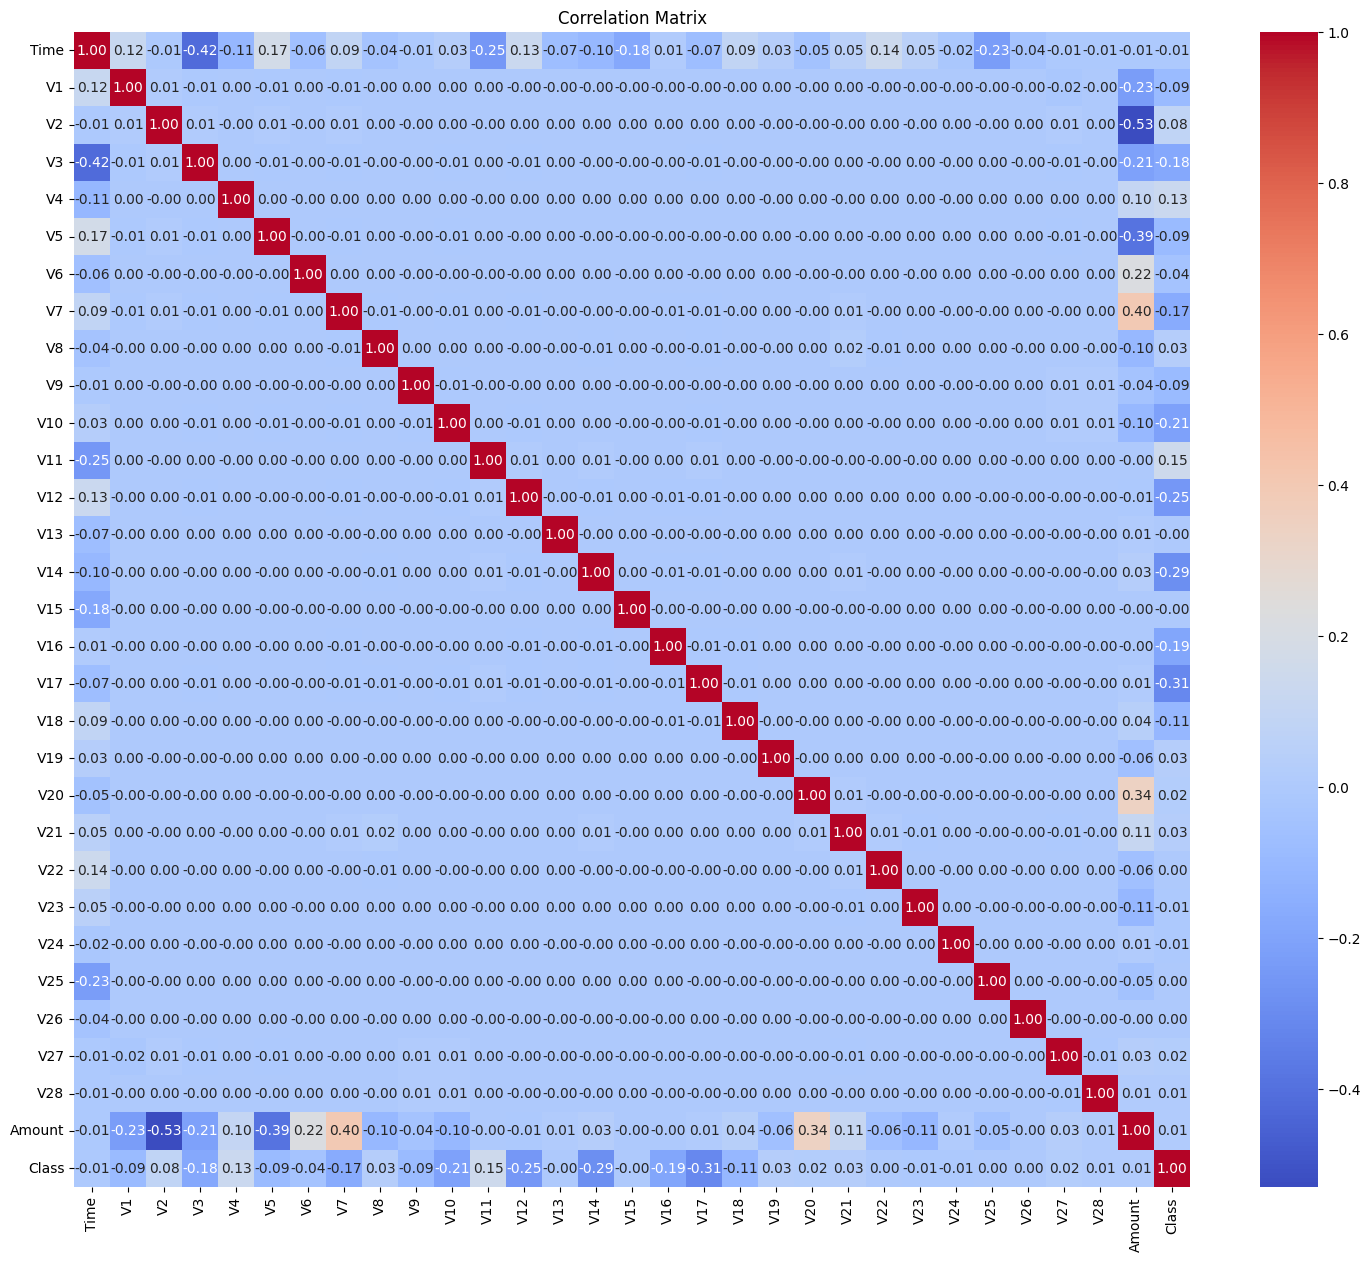

In [ ]:
# Calculate correlation matrix
corr = data.corr()

# Generate plot
plt.figure(figsize=(18, 15))
sns.heatmap(corr.round(2),  # Round correlation values to 2 decimal places
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            cmap='coolwarm',
            annot=True,
            fmt=".2f")  # Format annotation values to two decimal places

plt.title('Correlation Matrix')
plt.savefig('corr_matrix.png')
plt.show()

**Variance Inflation Factor (VIF)**

In [ ]:
# Calculate VIF for each feature
vif = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

print('Feature\tVIF')
for i, v in enumerate(vif):
    print(f'{data.columns[i]}\t{round(v,2)}')

Feature	VIF
Time	2.35
V1	1.64
V2	3.94
V3	1.32
V4	1.18
V5	2.77
V6	1.53
V7	2.6
V8	1.1
V9	1.04
V10	1.21
V11	1.08
V12	1.16
V13	1.0
V14	1.22
V15	1.01
V16	1.08
V17	1.23
V18	1.03
V19	1.04
V20	2.24
V21	1.1
V22	1.08
V23	1.15
V24	1.0
V25	1.01
V26	1.0
V27	1.01
V28	1.0
Amount	11.66
Class	2.03


**Observation**
*   The features with highest VIF are Amount (11.51) and V2 (3.9) which indicate high collinearity.
*   V5, V7, V20 also have moderately high VIF values between 2.5-3.
*   As per the above test results, It is better to remove highly correlated features to reduce dimensionality (V2, V5, V6, V7, V8, V20, V21, V22)



In [ ]:
# List of correlated features to remove
remove_cols = ['V2', 'V5', 'V6', 'V7', 'V8', 'V20', 'V21', 'V22']

# Drop the correlated features
data.drop(columns=remove_cols, inplace=True)

# View remaining columns
print(data.columns)

# Optional - double check correlations
corr_matrix = data.corr()
print(corr_matrix)

Index(['Time', 'V1', 'V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
       'V15', 'V16', 'V17', 'V18', 'V19', 'V23', 'V24', 'V25', 'V26', 'V27',
       'V28', 'Amount', 'Class'],
      dtype='object')
            Time        V1        V3        V4        V9       V10       V11  \
Time    1.000000  0.117927 -0.422054 -0.105845 -0.007861  0.031068 -0.248536   
V1      0.117927  1.000000 -0.008112  0.002257  0.001828  0.000815  0.001028   
V3     -0.422054 -0.008112  1.000000  0.002829 -0.003579 -0.009632  0.002339   
V4     -0.105845  0.002257  0.002829  1.000000  0.002154  0.002753 -0.001223   
V9     -0.007861  0.001828 -0.003579  0.002154  1.000000 -0.012613 -0.000217   
V10     0.031068  0.000815 -0.009632  0.002753 -0.012613  1.000000  0.000844   
V11    -0.248536  0.001028  0.002339 -0.001223 -0.000217  0.000844  1.000000   
V12     0.125500 -0.001524 -0.005900  0.003366 -0.002385 -0.006942  0.005569   
V13    -0.065958 -0.000568  0.000113  0.000177  0.000745  0.001379  0.000

## **Splitting data into training and testing datasets**

**Stratified splitting**


*   When creating a split between training and validation datasets, stratified splitting ensures that the proportions of classes remain the same in each split.
*   The division of datasets is typically done randomly based on a target variable. However, this can result in different proportions of the target variable across the splits, particularly with smaller datasets.

In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']

# Split data into training and temporary data (70% training and 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary data into validation and testing data (50% validation and 50% testing)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [ ]:
# Verify split distributions
print("Training Data:")
print(f"X_train length: {len(X_train)}")
print(f"Fraud percentage: {sum(y_train==1)/len(y_train)*100:.2f}%")
print(f"Non-fraud percentage: {sum(y_train==0)/len(y_train)*100:.2f}%")

print("\nValidation Data:")
print(f"X_val length: {len(X_val)}")
print(f"Fraud percentage: {sum(y_val==1)/len(y_val)*100:.2f}%")
print(f"Non-fraud percentage: {sum(y_val==0)/len(y_val)*100:.2f}%")

print("\nTesting Data:")
print(f"X_test length: {len(X_test)}")
print(f"Fraud percentage: {sum(y_test==1)/len(y_test)*100:.2f}%")
print(f"Non-fraud percentage: {sum(y_test==0)/len(y_test)*100:.2f}%")


Training Data:
X_train length: 198608
Fraud percentage: 0.17%
Non-fraud percentage: 99.83%

Validation Data:
X_val length: 42559
Fraud percentage: 0.17%
Non-fraud percentage: 99.83%

Testing Data:
X_test length: 42559
Fraud percentage: 0.17%
Non-fraud percentage: 99.83%


### **Feature Scaling**

**Performing Logarithm Scaling**

*   The logarithm function helps increase the distance between small numbers and decrease the distance between larger numbers. This is particularly useful when dealing with features that have dense values in small ranges. By increasing these intervals, our models can effectively improve their performance during training and testing with these specific values.
*   Scale train and test data separately to avoid data leakage.
*   Apply same scaling to new unseen data.

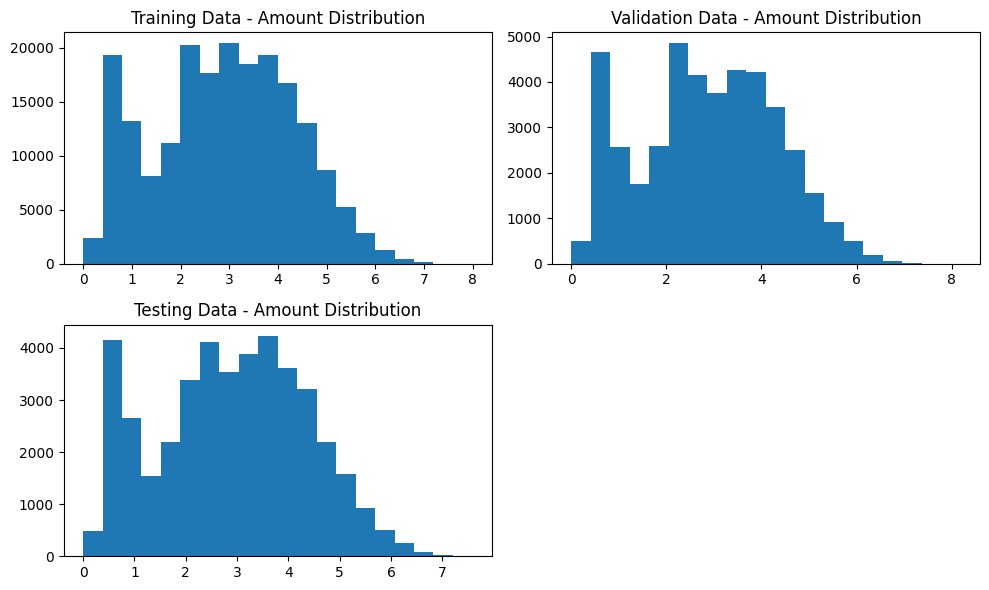

In [ ]:
# Add constant to make amounts positive
X_train['Amount'] += abs(X_train['Amount'].min()) + 1
X_val['Amount'] += abs(X_val['Amount'].min()) + 1
X_test['Amount'] += abs(X_test['Amount'].min()) + 1

# Apply box-cox transform
transformer = PowerTransformer(method='box-cox', standardize=False)
transformer.fit(X_train[['Amount']])

X_train['Amount'] = transformer.transform(X_train[['Amount']])
X_val['Amount'] = transformer.transform(X_val[['Amount']])
X_test['Amount'] = transformer.transform(X_test[['Amount']])

# Verify distributions
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.hist(X_train['Amount'], bins=20)
plt.title("Training Data - Amount Distribution")

plt.subplot(2, 2, 2)
plt.hist(X_val['Amount'], bins=20)
plt.title("Validation Data - Amount Distribution")

plt.subplot(2, 2, 3)
plt.hist(X_test['Amount'], bins=20)
plt.title("Testing Data - Amount Distribution")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

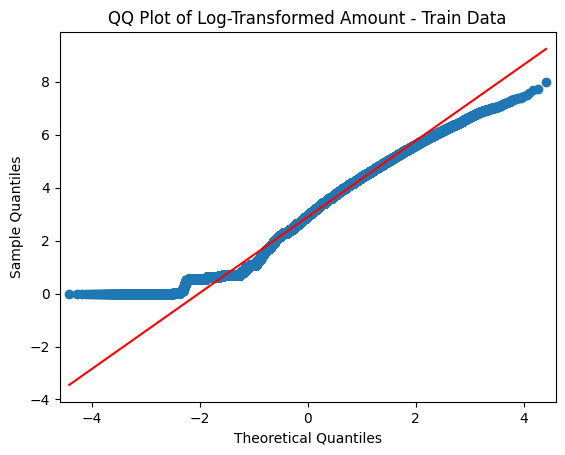

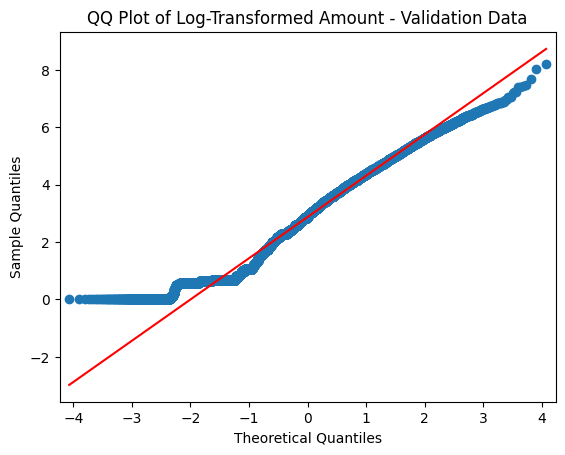

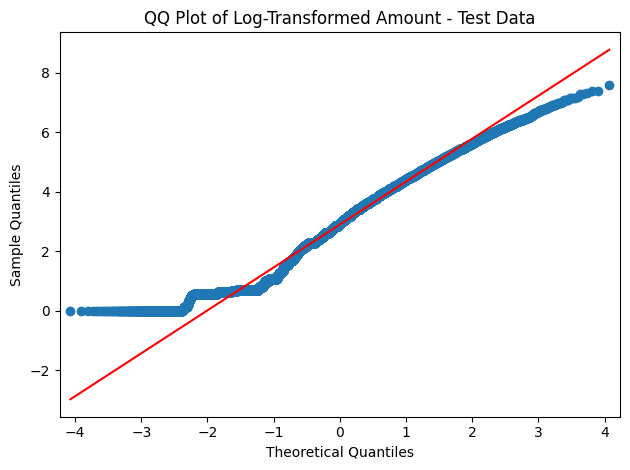

In [ ]:
# Create QQ plots for both train and test data
plt.figure(figsize=(10, 6))
sm.qqplot(X_train['Amount'], line='s')
plt.title('QQ Plot of Log-Transformed Amount - Train Data')
sm.qqplot(X_val['Amount'], line='s')
plt.title('QQ Plot of Log-Transformed Amount - Validation Data')
sm.qqplot(X_test['Amount'], line='s')
plt.title('QQ Plot of Log-Transformed Amount - Test Data')
plt.tight_layout()
plt.show()


**Observation**

*   It can be seen that the skewness has improved a lot as shown in the pictures above.
*   The Histogram shows bell shaped plots, better than right skewed.




### **Resampling techniques**

**Oversample/undersample before or after splitting data?**

*   The rule of thumb is: **never mess up with your test set**. Always split into test and train sets BEFORE trying oversampling/undersampling techniques!
*   It is not advisable to oversample before splitting the data as it can lead to the same observations being present in both the test and train sets. This can make the model memorize specific data points and cause overfitting, resulting in poor generalization to the test data. Similarly, data leakage can create overly optimistic or completely invalid predictive models. It is important to avoid these issues to ensure accurate and reliable results.



#### **Handling Data Imbalance using SMOTE combined with stratification**

In [ ]:
# Apply SMOTE with stratified sampling to balance the log-transformed training data
smote = SMOTE(sampling_strategy = 'auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Print the class distribution before and after SMOTE for training data
print("Training Data - Class distribution before SMOTE:")
print(y_train.value_counts())
print("\nTraining Data - Class distribution after SMOTE:")
print(y_train_resampled.value_counts())

Training Data - Class distribution before SMOTE:
0    198277
1       331
Name: Class, dtype: int64

Training Data - Class distribution after SMOTE:
0    198277
1    198277
Name: Class, dtype: int64


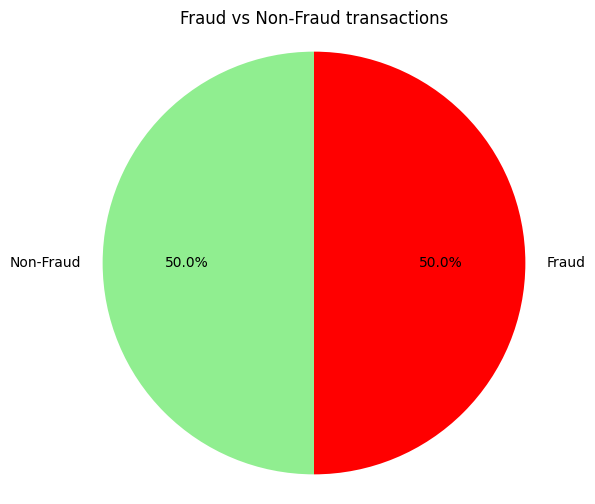

Non-Fraud (Training Data after SMOTE): 50.0 % of the dataset
Fraud (Training Data after SMOTE): 50.0 % of the dataset


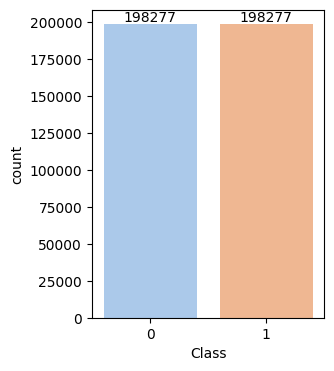

In [ ]:
# Data
labels = ["Non-Fraud", "Fraud"]
class_value_counts = y_train_resampled.value_counts().tolist()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(class_value_counts, labels=labels, colors=["lightgreen", "red"], autopct="%1.1f%%", startangle=90)
plt.title("Fraud vs Non-Fraud transactions")
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the chart
plt.show()

# Create the countplot for training data after SMOTE
plt.figure(figsize=(3, 4))
ax = sns.countplot(x=y_train_resampled, palette="pastel")
for i in ax.containers:
    ax.bar_label(i)

# Print the percentage of each class in the training data after SMOTE
print('Non-Fraud (Training Data after SMOTE):', round(y_train_resampled.value_counts()[0] / len(y_train_resampled) * 100, 3), '% of the dataset')
print('Fraud (Training Data after SMOTE):', round(y_train_resampled.value_counts()[1] / len(y_train_resampled) * 100, 3), '% of the dataset')

**Observation**:

*   As seen in the above plots, SMOTE has resampled the dataset and balanced the dataset.

#### **Handling Data Imbalance using Random Undersampling**

In [ ]:
# Apply Random Undersampling technique to balance the log-transformed training data
random_undersample = RandomUnderSampler(random_state=42)
X_train_random_undersampled, y_train_random_undersampled = random_undersample.fit_resample(X_train, y_train)

# Print the class distribution before and after Random Undersampling for training data
print("Training Data - Class distribution before Random Undersampling:")
print(y_train.value_counts())
print("\nTraining Data - Class distribution after Random Undersampling:")
print(y_train_random_undersampled.value_counts())

Training Data - Class distribution before Random Undersampling:
0    198277
1       331
Name: Class, dtype: int64

Training Data - Class distribution after Random Undersampling:
0    331
1    331
Name: Class, dtype: int64


**Observation**:

*   The Random Undersampling techique balanced the dataset, but with huge data loss.
*   As Random undersampling removes data at random without information about the datapoints, we might have lost influential data.
*   Therefore, we are not going to use the Random Undersampled data for further investigation.

#### **Handling Data Imbalance using Tomek Links**

In [ ]:
# Apply Undersampling using Tomek Links to balance the log-transformed training data
tomek_undersample = TomekLinks()
X_train_tomek_undersampled, y_train_tomek_undersampled = tomek_undersample.fit_resample(X_train, y_train)

# Print the class distribution before and after Tomek Links undersampling for training data
print("Training Data - Class distribution before Tomek Links undersampling:")
print(y_train.value_counts())
print("\nTraining Data - Class distribution after Tomek Links undersampling:")
print(y_train_tomek_undersampled.value_counts())

Training Data - Class distribution before Tomek Links undersampling:
0    198277
1       331
Name: Class, dtype: int64

Training Data - Class distribution after Tomek Links undersampling:
0    198265
1       331
Name: Class, dtype: int64


**Observation**:

*   As Tomek links undersmaples based on nearest neighbours, it did not balance our highly imbalanced dataset.
*   Therefore, we are not going to use the Tomek links undersampled data from further investigation.

## **Model Selection**

### **Evaluation metrics**

In [ ]:
def evaluate_model(model, X_data, y_data, data_type):

  # Get predictions
  y_pred = model.predict(X_data)
  y_prob = model.predict_proba(X_data)[:, 1]

  # Calculate metrics
  precision = precision_score(y_data, y_pred)
  recall = recall_score(y_data, y_pred)
  f1 = f1_score(y_data, y_pred)
  auc_roc = roc_auc_score(y_data, y_prob)
  cm = confusion_matrix(y_data, y_pred)  # Confusion matrix

  # Precision-Recall Curve
  precision_curve, recall_curve, _ = precision_recall_curve(y_data, y_prob)
  auprc = auc(recall_curve, precision_curve)

  # Plot PR Curve
  plt.figure()
  plt.plot(recall_curve, precision_curve, marker='.')
  plt.fill_between(recall_curve, precision_curve, alpha=0.2)
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'AUPRC: {auprc:.2f}')
  plt.show()

  # Display Confusion Matrix
  plt.figure()
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 14})
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # Return metrics
  metrics = {
    'Precision': np.mean(precision),
    'Recall': np.mean(recall),
    'F1-Score': f1,
    'AUC-ROC': auc_roc,
    'AUPRC': auprc
  }

  return metrics

## **Individual Base Models**

**Train Base Models with the SMOTE resampled trainig dataset.**

### **Logistic Regression**

In [ ]:
# Initialize the individual base models
logistic_regression = LogisticRegression(random_state=42)

# Train the Logistic Regression base model
logistic_regression.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

### **Ramdon Forest**

In [ ]:
# Initialize the individual base models
random_forest = RandomForestClassifier(random_state=42)

# Train the Random Forest base model
random_forest.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

**Feature importance of RF**

Feature: V14, Importance: 0.21922566802756155
Feature: V10, Importance: 0.15681993213990084
Feature: V12, Importance: 0.14697488551079163
Feature: V4, Importance: 0.10488303365058309
Feature: V3, Importance: 0.08311981177533145
Feature: V17, Importance: 0.06310528042196971
Feature: V11, Importance: 0.051650241104767174
Feature: V16, Importance: 0.03432187403590243
Feature: V9, Importance: 0.03321186396917952
Feature: V18, Importance: 0.01943901502867634
Feature: V1, Importance: 0.016605936655916514
Feature: V27, Importance: 0.014245449089959948
Feature: Time, Importance: 0.008284117923185506
Feature: V28, Importance: 0.006925865846989792
Feature: V19, Importance: 0.006579686380112876
Feature: Amount, Importance: 0.005751556755692976
Feature: V13, Importance: 0.005674843327706417
Feature: V26, Importance: 0.005317347287213578
Feature: V15, Importance: 0.0050380846840927
Feature: V23, Importance: 0.004509557370082838
Feature: V24, Importance: 0.0041910029066475375
Feature: V25, Importanc

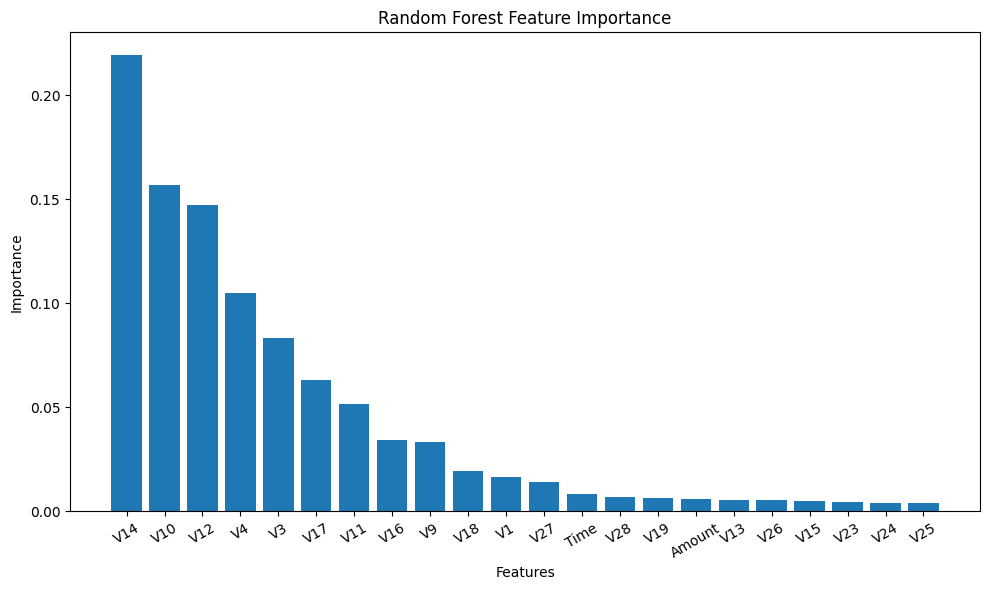

In [ ]:
# Get feature importances
feature_importances = random_forest.feature_importances_

# Get the names of your features
feature_names = list(X.columns)

#Ceate a dictionary of feature importance with feature names
feature_importance_pairs = {feature: importance for feature , importance in zip(feature_names, feature_importances)}

# Sort the list by feature importance in descending order
feature_importance_pairs = dict(sorted(feature_importance_pairs.items(), key=lambda x: x[1], reverse=True))

# Print the feature importance
for feature, importance in feature_importance_pairs.items():
    print(f"Feature: {feature}, Importance: {importance}")

# PLotting the feature importance
plt.figure(figsize = (10,6))
plt.bar(feature_importance_pairs.keys(), feature_importance_pairs.values())
plt.xticks(rotation = 30)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

#### **XGBoost**

In [ ]:
# Initialize the individual base models
xgboost = XGBClassifier(random_state=42)

# Train the XGBoost base model
xgboost.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

**Feature Importance of xgboost model**

Feature: V14, Importance: 0.7030122876167297
Feature: V12, Importance: 0.0588175505399704
Feature: V4, Importance: 0.04828634858131409
Feature: V17, Importance: 0.03360222652554512
Feature: V3, Importance: 0.018409322947263718
Feature: V9, Importance: 0.015249502845108509
Feature: V10, Importance: 0.011665485799312592
Feature: V25, Importance: 0.010993068106472492
Feature: V19, Importance: 0.010858718305826187
Feature: V1, Importance: 0.0106648039072752
Feature: V11, Importance: 0.010392211377620697
Feature: V18, Importance: 0.009211634285748005
Feature: V16, Importance: 0.00783380214124918
Feature: Amount, Importance: 0.006928985007107258
Feature: V13, Importance: 0.006380731239914894
Feature: V15, Importance: 0.006228079553693533
Feature: V26, Importance: 0.005901169031858444
Feature: V24, Importance: 0.005593670532107353
Feature: Time, Importance: 0.005158703774213791
Feature: V23, Importance: 0.005066326353698969
Feature: V28, Importance: 0.004908649250864983
Feature: V27, Importan

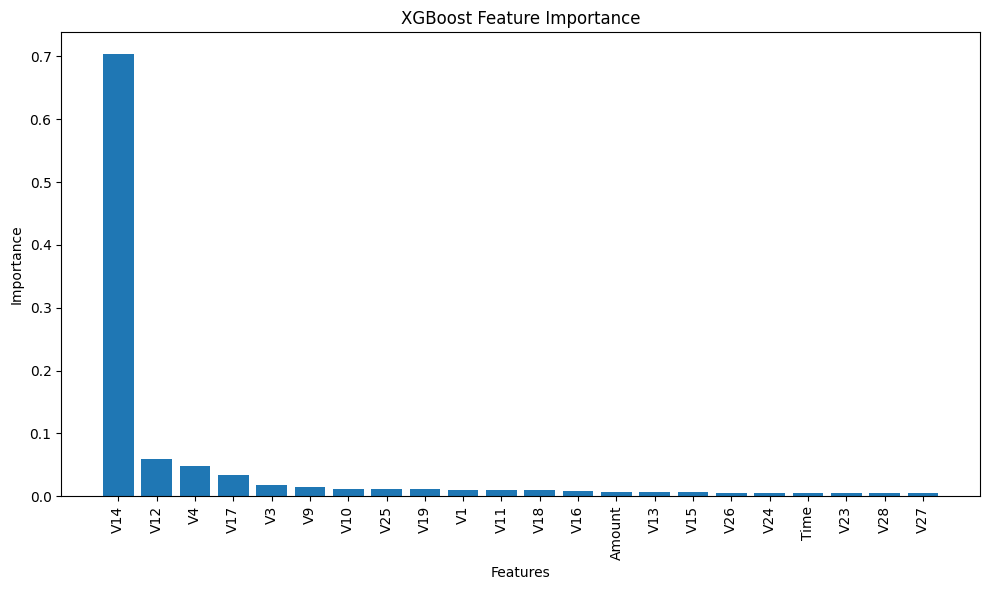

In [ ]:
# Get feature importances
feature_importances = xgboost.feature_importances_

# Get the names of your features
feature_names = list(X.columns)

# Create a dictionary of feature importance with feature names
feature_importance_dict = {feature: importance for feature, importance in zip(feature_names, feature_importances)}

# Sort the dictionary by feature importance in descending order
sorted_feature_importance = dict(sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True))

# Print the feature importance
for feature, importance in sorted_feature_importance.items():
    print(f"Feature: {feature}, Importance: {importance}")

# Plotting the feature importances
plt.figure(figsize=(10, 6))
plt.bar(sorted_feature_importance.keys(), sorted_feature_importance.values())
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

As I faced the issue of ovrfitting even after hyperparameter tuning, I am removing features based on the Feature importance of random forest model and XGBoost model.



*   V13: Low importance in both models (0.006 in RF, 0.007 in XGB)
*   V15: Low importance in both models (0.005 in RF, 0.006 in XGB)
*   V23: Very low importance in both models (0.005 in RF, 0.005 in XGB)
*   V24: Low importance in both models (0.004 in RF, 0.006 in XGB)
*   V25: Low in RF (0.004) despite higher in XGB (0.011)
*   V26: Low in both models (0.005 in RF, 0.006 in XGB)
*   V27: Low in both models (0.014 in RF, 0.005 in XGB)
*   V28: Low in both models (0.007 in RF, 0.005 in XGB)

In [ ]:
# List of low importance features to drop
drop_cols = ['V13', 'V15', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

# Drop the low importance features in the Training, Validation and testing set to maintiain balance in all sets.
X_train_resampled.drop(columns=drop_cols, inplace=True)
X_val.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

### **Hyperparameter Tuning for Base Models**

#### **Logistic Regression**

In [ ]:
# Define the parameter grid for Lasso regularization (alpha is the penalty strength)
param_grid_lasso = {
    'C': np.logspace(-3, 3, 7)  # Using C as the inverse of alpha
}

# Create a LogisticRegression object with Lasso regularization
logistic_regression_lasso = LogisticRegression(penalty='l1', solver='liblinear')

# Create RandomizedSearchCV object for hyperparameter tuning with Lasso
random_search_lr = RandomizedSearchCV(logistic_regression_lasso, param_distributions=param_grid_lasso,
                                         n_iter=10, cv=5, scoring='f1', n_jobs=-1)

# Perform random search hyperparameter tuning with Lasso on the resampled data
random_search_lr.fit(X_train_resampled, y_train_resampled)

# Get the best Lasso model after hyperparameter tuning
best_model_lr = random_search_lr.best_estimator_

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 7 is smaller than n_iter=10. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
# Get the best parameters and best estimator from the grid search
best_params_lr = random_search_lr.best_params_

# Print the best parameters
print("Best Parameters for Logistic Regression model:", best_params_lr)

Best Parameters for Logistic Regression model: {'C': 1.0}


**Evaluate hypertuned Logistic Regression model on the Validation dataset.**

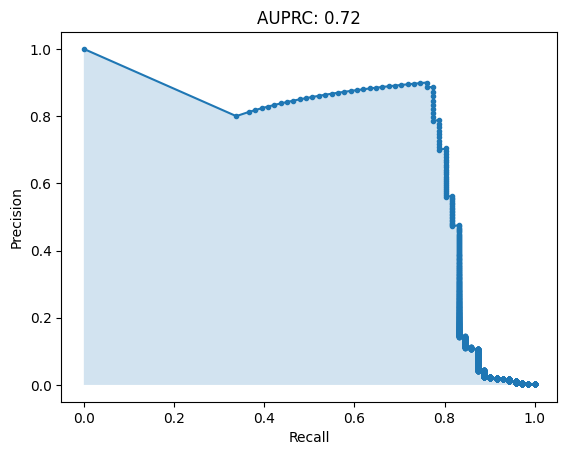

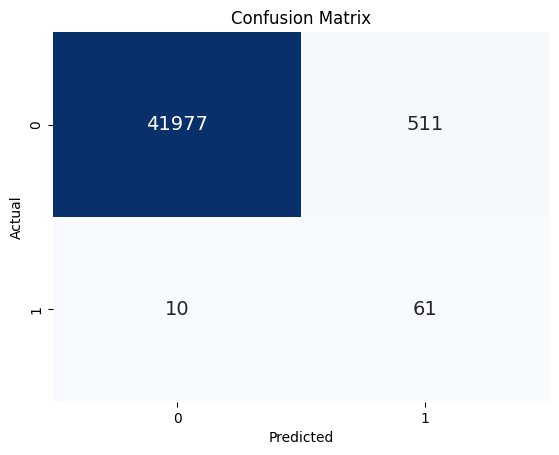

Metrics for Logistic Regression on Validation Data:
{'Precision': 0.10664335664335664, 'Recall': 0.8591549295774648, 'F1-Score': 0.18973561430793157, 'AUC-ROC': 0.9748316674666716, 'AUPRC': 0.7233261181878766}


In [ ]:
# Evaluate Logistic Regression on validation set
validation_metrics_lr = evaluate_model(best_model_lr, X_val, y_val, data_type='Validation (Logistic Regression)')
print("Metrics for Logistic Regression on Validation Data:")
print(validation_metrics_lr)

### **Random Foest model**

In [ ]:
param_grid_rf = {
    'n_estimators': [10, 20, 30],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

# Create RandomizedSearchCV objects for hyperparameter tuning
random_search_rf = RandomizedSearchCV(random_forest, param_distributions=param_grid_rf,
                                      n_iter=30, cv=3, scoring='f1', n_jobs=-1)

# Perform random search hyperparameter tuning on each model
random_search_rf.fit(X_train_resampled, y_train_resampled)

# Get the best models after hyperparameter tuning
best_model_rf = random_search_rf.best_estimator_

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 27 is smaller than n_iter=30. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
# Get the best parameters and best estimator from the grid search
best_params_rf = random_search_rf.best_params_

# Print the best parameters
print("Best Parameters for Random forest model:", best_params_rf)

Best Parameters for Random forest model: {'n_estimators': 30, 'min_samples_leaf': 1, 'max_depth': 20}


**Evaluate Random Forest on the Validation dataset.**

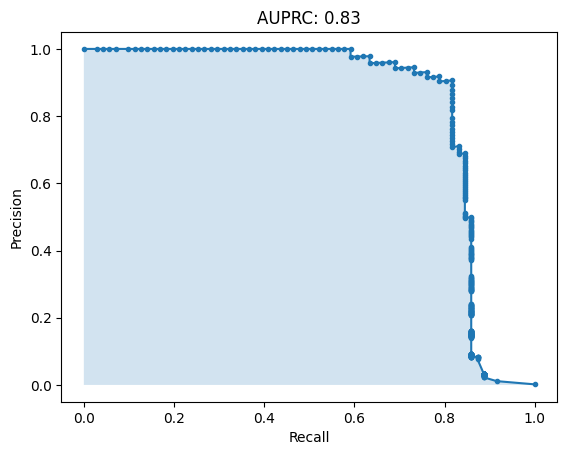

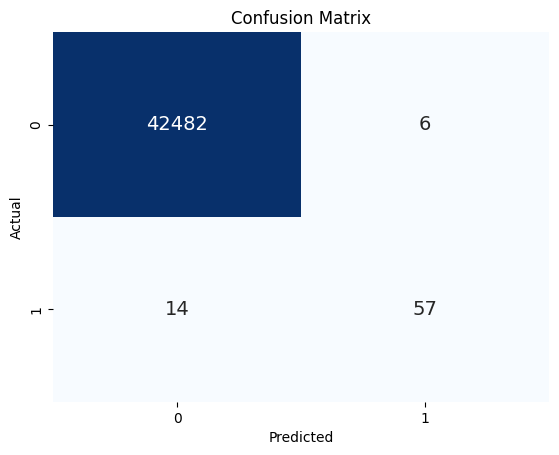

Metrics for Random Forest on Validation Data:
{'Precision': 0.9047619047619048, 'Recall': 0.8028169014084507, 'F1-Score': 0.8507462686567164, 'AUC-ROC': 0.9485874719224784, 'AUPRC': 0.8339246738340234}


In [ ]:
# Evaluate Random Forest on validation set
validation_metrics_rf = evaluate_model(best_model_rf, X_val, y_val, data_type='Validation (Random Forest)')
print("Metrics for Random Forest on Validation Data:")
print(validation_metrics_rf)

#### **XGBoost model**

In [ ]:
param_grid_xgb = {
    'n_estimators': [10, 20, 30],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Create RandomizedSearchCV objects for hyperparameter tuning
random_search_xgb = RandomizedSearchCV(xgboost, param_distributions=param_grid_xgb,
                                       n_iter=30, cv=3, scoring='f1', n_jobs=-1)

# Perform random search hyperparameter tuning on each model
random_search_xgb.fit(X_train_resampled, y_train_resampled)

# Get the best models after hyperparameter tuning
best_model_xgb = random_search_xgb.best_estimator_

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 27 is smaller than n_iter=30. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
# Get the best parameters and best estimator from the grid search
best_params_xgb = random_search_xgb.best_params_

# Print the best parameters
print("Best Parameters for XGBoost model:", best_params_xgb)

Best Parameters for XGBoost model: {'n_estimators': 30, 'max_depth': 5, 'learning_rate': 0.2}


**Evaluate hyperparameter-tuned XGBoost model on the validation dataset.**

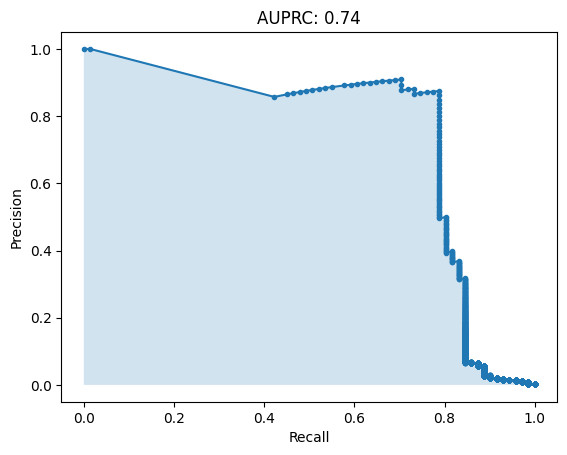

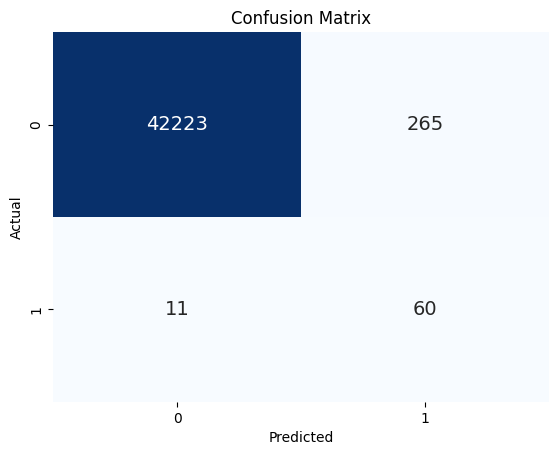

Metrics for XGBoost on Validation Data:
{'Precision': 0.18461538461538463, 'Recall': 0.8450704225352113, 'F1-Score': 0.30303030303030304, 'AUC-ROC': 0.9810705458508915, 'AUPRC': 0.7435768931524888}


In [ ]:
# Evaluate XGBoost on validation set
validation_metrics_xgb = evaluate_model(best_model_xgb, X_val, y_val, data_type='Validation (XGBoost)')
print("Metrics for XGBoost on Validation Data:")
print(validation_metrics_xgb)

### **Ensemble Model (Stacking multiple models)**

Train a meta-model (gradient boosting) on the predictions of the base models. Use the validation set to ensure that the meta-model can effectively learn how to combine the predictions from different base models.

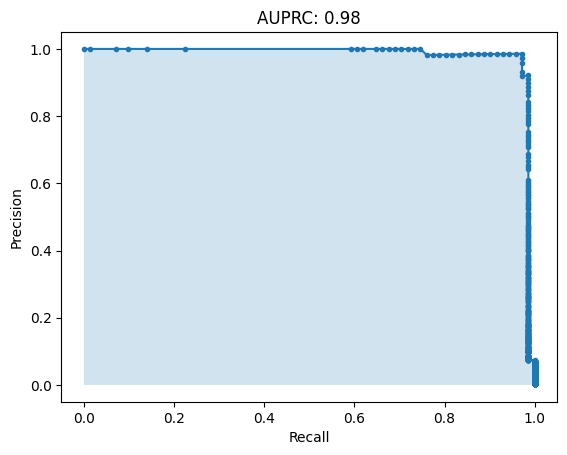

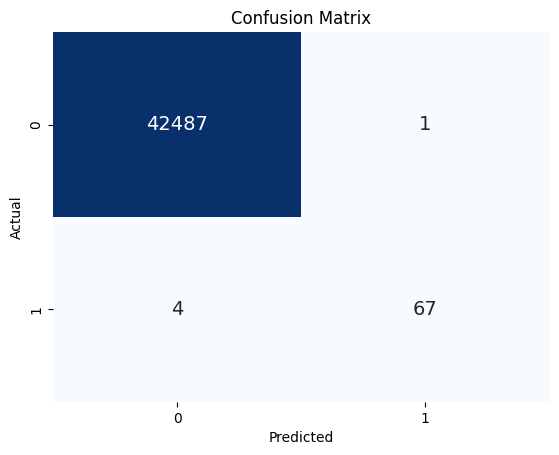

Metrics for Meta-Model on Validation Data:
{'Precision': 0.9852941176470589, 'Recall': 0.9436619718309859, 'F1-Score': 0.9640287769784172, 'AUC-ROC': 0.9997011583718088, 'AUPRC': 0.9823159724160025}


In [ ]:
# Create a DataFrame to store the predictions of base models on the validation set
# Make predictions on validation set
rf_predictions = best_model_rf.predict_proba(X_val)[:,1]
xgb_predictions = best_model_xgb.predict_proba(X_val)[:,1]
lr_predictions = best_model_lr.predict_proba(X_val)[:,1]

# Get minimum length
min_len = min(len(rf_predictions), len(xgb_predictions), len(lr_predictions))

# Truncate y_val to match prediction length
y_val_resampled = y_val[:min_len]

# Truncate predictions
rf_predictions = rf_predictions[:min_len]
xgb_predictions = xgb_predictions[:min_len]
lr_predictions = lr_predictions[:min_len]

# Create prediction dataframe
base_model_predictions = pd.DataFrame({
  'Random Forest': rf_predictions,
  'XGBoost': xgb_predictions,
  'Logistic Regression': lr_predictions
})

# Train meta model
meta_model = XGBClassifier(random_state=42)
meta_model.fit(base_model_predictions, y_val)

# Evaluate meta model
validation_metrics_meta = evaluate_model(meta_model, base_model_predictions, y_val, 'Meta Model')
# Make predictions on validation set
print("Metrics for Meta-Model on Validation Data:")
print(validation_metrics_meta)

#### **Performance of each model on the validation dataset**

In [ ]:
# Create a dictionary to store the model results
model_results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble'],
    'Precision': [validation_metrics_lr['Precision'], validation_metrics_rf['Precision'], validation_metrics_xgb['Precision'], validation_metrics_meta['Precision']],
    'Recall': [validation_metrics_lr['Recall'], validation_metrics_rf['Recall'], validation_metrics_xgb['Recall'], validation_metrics_meta['Recall']],
    'F1-Score': [validation_metrics_lr['F1-Score'], validation_metrics_rf['F1-Score'], validation_metrics_xgb['Precision'], validation_metrics_meta['F1-Score']],
    'AOC-ROC': [validation_metrics_lr['AUC-ROC'], validation_metrics_rf['AUC-ROC'], validation_metrics_xgb['AUC-ROC'], validation_metrics_meta['AUC-ROC']],
    'AUPRC': [validation_metrics_lr['AUPRC'], validation_metrics_rf['AUPRC'], validation_metrics_xgb['AUPRC'], validation_metrics_meta['AUPRC']]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(model_results)

# Print the table using the tabulate library
table = tabulate(results_df, headers='keys', tablefmt='grid')
print(table)

+----+---------------------+-------------+----------+------------+-----------+----------+
|    | Model               |   Precision |   Recall |   F1-Score |   AOC-ROC |    AUPRC |
+====+=====================+=============+==========+============+===========+==========+
|  0 | Logistic Regression |    0.106643 | 0.859155 |   0.189736 |  0.974832 | 0.723326 |
+----+---------------------+-------------+----------+------------+-----------+----------+
|  1 | Random Forest       |    0.904762 | 0.802817 |   0.850746 |  0.948587 | 0.833925 |
+----+---------------------+-------------+----------+------------+-----------+----------+
|  2 | XGBoost             |    0.184615 | 0.84507  |   0.184615 |  0.981071 | 0.743577 |
+----+---------------------+-------------+----------+------------+-----------+----------+
|  3 | Ensemble            |    0.985294 | 0.943662 |   0.964029 |  0.999701 | 0.982316 |
+----+---------------------+-------------+----------+------------+-----------+----------+


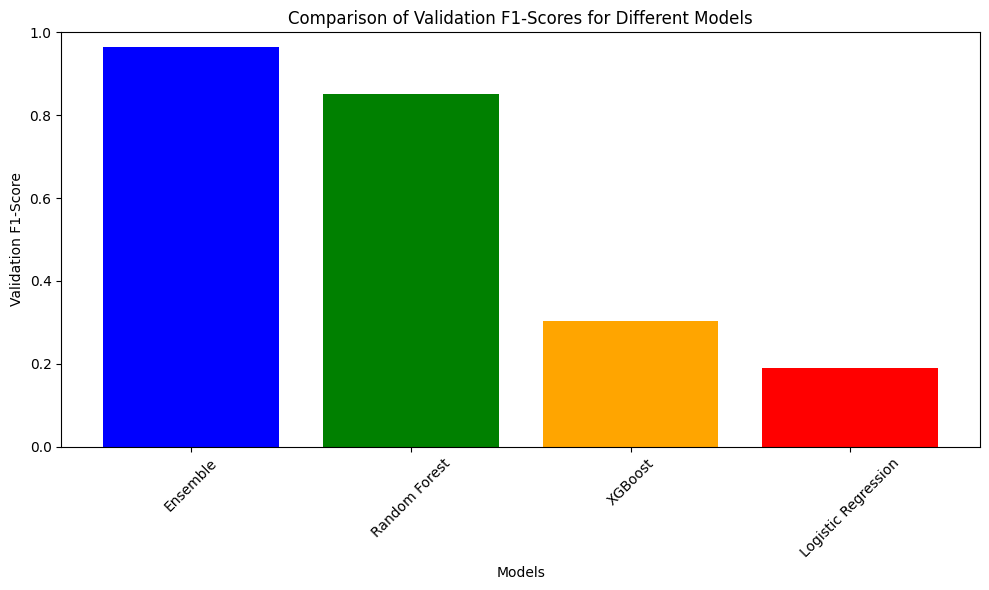

In [ ]:
# Create a dictionary to store the F1-Scores for each model on validation data
validation_f1_scores = {
    'Logistic Regression': validation_metrics_lr['F1-Score'],
    'Random Forest': validation_metrics_rf['F1-Score'],
    'XGBoost': validation_metrics_xgb['F1-Score'],
    'Ensemble': validation_metrics_meta['F1-Score']
}

# Sort the models based on their validation F1-Scores in descending order
sorted_models = sorted(validation_f1_scores.items(), key=lambda x: x[1], reverse=True)

# Extract sorted model names and validation F1-Scores
model_names = [model[0] for model in sorted_models]
f1_scores_values = [model[1] for model in sorted_models]

# Create a bar plot for validation F1-Scores
plt.figure(figsize=(10, 6))
plt.bar(model_names, f1_scores_values, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Models')
plt.ylabel('Validation F1-Score')
plt.title('Comparison of Validation F1-Scores for Different Models')
plt.ylim(0, 1)  # Set the y-axis limits
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

**Observation**:

*   The ensemble model is performing best when compared to all individual models.
*   TheRandom Forest performed best in between individual models.

## **Test on the testing data**

### **Logistic regression**

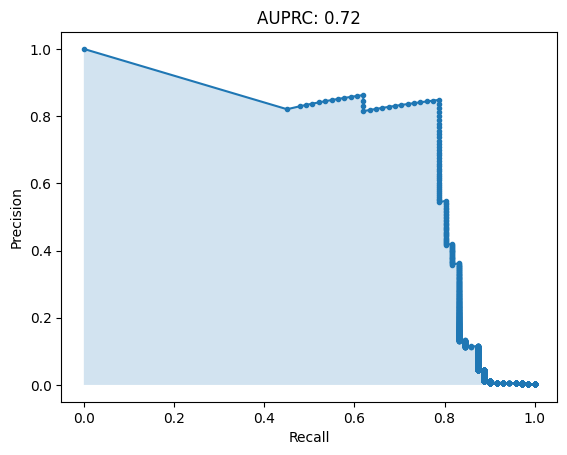

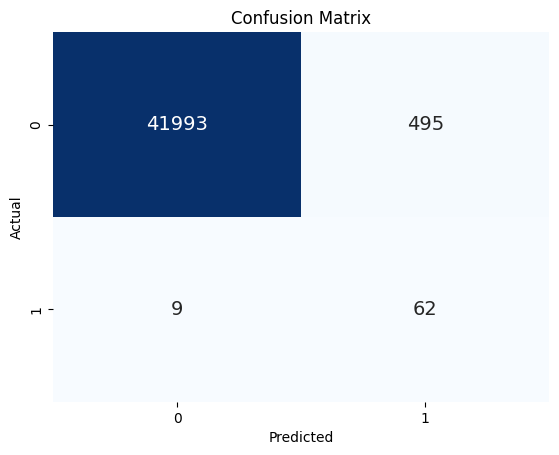

Metrics for Logistic Regression on Testing Data:
{'Precision': 0.11131059245960502, 'Recall': 0.8732394366197183, 'F1-Score': 0.19745222929936304, 'AUC-ROC': 0.9521541790755833, 'AUPRC': 0.7185175835371399}


In [ ]:
# Use the best model to predict on the testing set
testing_predictions_lr = best_model_lr.predict(X_test)
testing_probabilities_lr = best_model_lr.predict_proba(X_test)[:, 1]

# Calculate metrics using the evaluate_model function
test_metrics_lr = evaluate_model(best_model_lr, X_test, y_test, data_type='Testing (Logistic Regression)')

# Print testing metrics
print("Metrics for Logistic Regression on Testing Data:")
print(test_metrics_lr)

### **Random Forest Model**

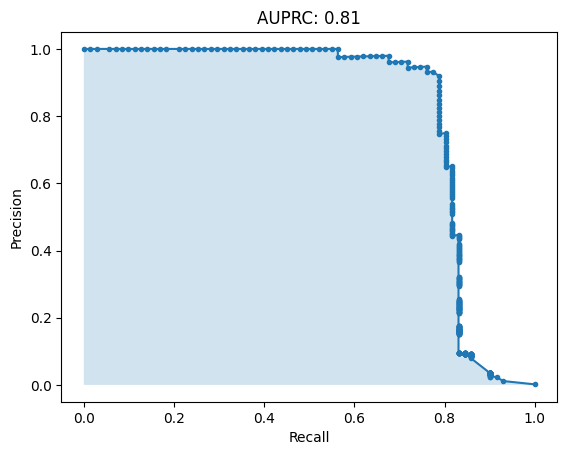

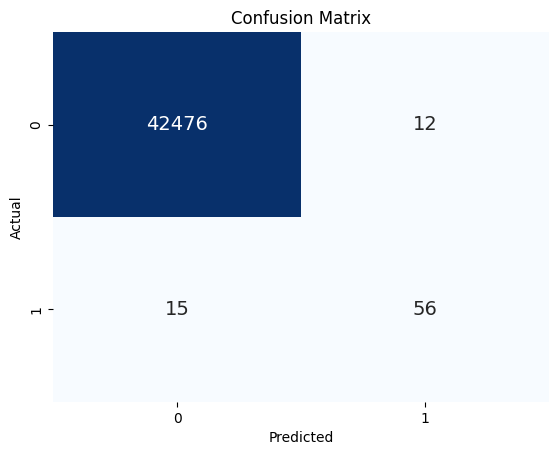

Metrics for Random Forest on Testing Data:
{'Precision': 0.8235294117647058, 'Recall': 0.7887323943661971, 'F1-Score': 0.8057553956834531, 'AUC-ROC': 0.9562254197374039, 'AUPRC': 0.8123057648061355}


In [ ]:
# Use the best model to predict on the testing set
testing_predictions_rf = best_model_rf.predict(X_test)
testing_probabilities_rf = best_model_rf.predict_proba(X_test)[:, 1]

# Calculate metrics using the evaluate_model function
test_metrics_rf = evaluate_model(best_model_rf, X_test, y_test, data_type='Testing (Random Forest)')

# Print testing metrics
print("Metrics for Random Forest on Testing Data:")
print(test_metrics_rf)

### **XGBoost model**

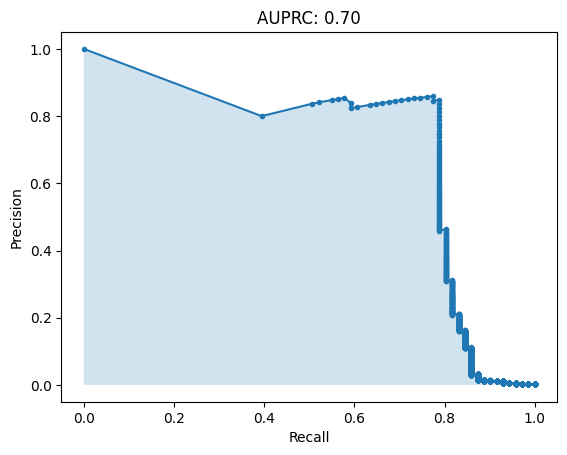

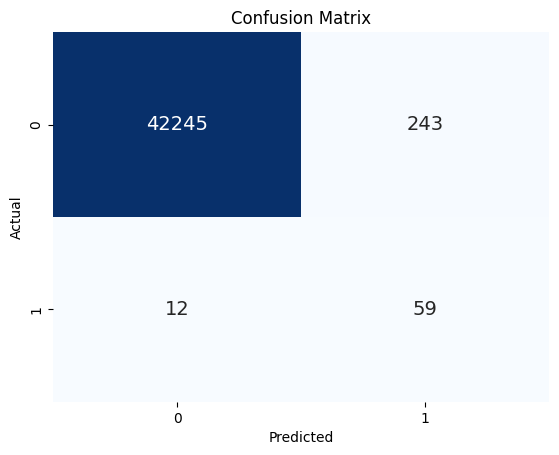

Metrics for XGBoost on Testing Data:
{'Precision': 0.19536423841059603, 'Recall': 0.8309859154929577, 'F1-Score': 0.3163538873994638, 'AUC-ROC': 0.9526774419819615, 'AUPRC': 0.7039880946519681}


In [ ]:
# Use the best model to predict on the testing set
testing_predictions_xgb = best_model_xgb.predict(X_test)
testing_probabilities_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics using the evaluate_model function
test_metrics_xgb = evaluate_model(best_model_xgb, X_test, y_test, data_type='Testing (XGBoost)')

# Print testing metrics
print("Metrics for XGBoost on Testing Data:")
print(test_metrics_xgb)

### **Emsemble model**

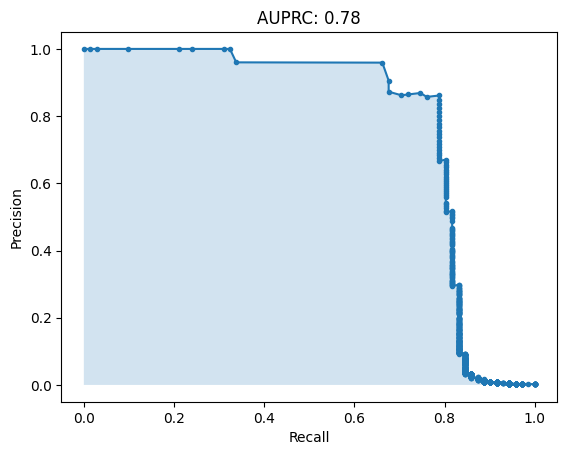

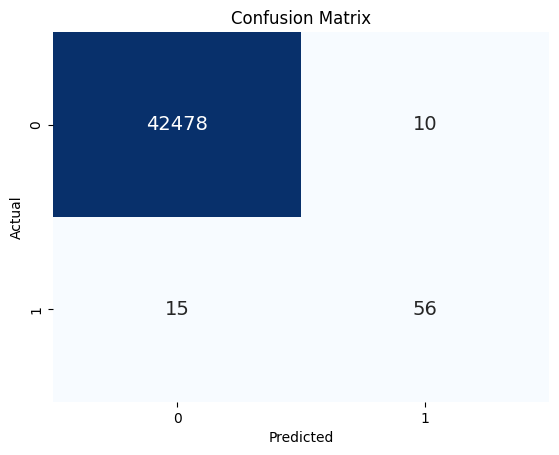

Metrics for Meta-Model on test Data:
{'Precision': 0.8484848484848485, 'Recall': 0.7887323943661971, 'F1-Score': 0.8175182481751825, 'AUC-ROC': 0.9513630692079421, 'AUPRC': 0.7828136640337255}


In [ ]:
# Create a DataFrame to store the predictions of base models on the test set
# Make predictions on test set
rf_test_predictions = best_model_rf.predict_proba(X_test)[:,1]
xgb_test_predictions = best_model_xgb.predict_proba(X_test)[:,1]
lr_test_predictions = best_model_lr.predict_proba(X_test)[:,1]

# Get minimum length
min_len = min(len(rf_test_predictions), len(xgb_test_predictions), len(lr_test_predictions))

# Truncate y_val to match prediction length
y_val_resampled = y_val[:min_len]

# Truncate predictions
rf_test_predictions = rf_test_predictions[:min_len]
xgb_test_predictions = xgb_test_predictions[:min_len]
lr_test_predictions = lr_test_predictions[:min_len]

# Create prediction dataframe
base_model_predictions_test = pd.DataFrame({
  'Random Forest': rf_test_predictions,
  'XGBoost': xgb_test_predictions,
  'Logistic Regression': lr_test_predictions
})


# Evaluate meta model
test_metrics_meta = evaluate_model(meta_model, base_model_predictions_test, y_test, 'Meta Model')
# Make predictions on validation set
print("Metrics for Meta-Model on test Data:")
print(test_metrics_meta)

### **Performance comparision of all models**

In [ ]:
# Create a dictionary to store the model results
model_results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble'],
    'Precision': [test_metrics_lr['Precision'], test_metrics_rf['Precision'], test_metrics_xgb['Precision'], test_metrics_meta['Precision']],
    'Recall': [test_metrics_lr['Recall'], test_metrics_rf['Recall'], test_metrics_xgb['Recall'], test_metrics_meta['Recall']],
    'F1-Score': [test_metrics_lr['F1-Score'], test_metrics_rf['F1-Score'], test_metrics_xgb['Precision'], test_metrics_meta['F1-Score']],
    'AOC-ROC': [test_metrics_lr['AUC-ROC'], test_metrics_rf['AUC-ROC'], test_metrics_xgb['AUC-ROC'], test_metrics_meta['AUC-ROC']],
    'AUPRC': [test_metrics_lr['AUPRC'], test_metrics_rf['AUPRC'], test_metrics_xgb['AUPRC'], test_metrics_meta['AUPRC']]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(model_results)

# Print the table using the tabulate library
table = tabulate(results_df, headers='keys', tablefmt='grid')
print(table)


+----+---------------------+-------------+----------+------------+-----------+----------+
|    | Model               |   Precision |   Recall |   F1-Score |   AOC-ROC |    AUPRC |
+====+=====================+=============+==========+============+===========+==========+
|  0 | Logistic Regression |    0.111311 | 0.873239 |   0.197452 |  0.952154 | 0.718518 |
+----+---------------------+-------------+----------+------------+-----------+----------+
|  1 | Random Forest       |    0.823529 | 0.788732 |   0.805755 |  0.956225 | 0.812306 |
+----+---------------------+-------------+----------+------------+-----------+----------+
|  2 | XGBoost             |    0.195364 | 0.830986 |   0.195364 |  0.952677 | 0.703988 |
+----+---------------------+-------------+----------+------------+-----------+----------+
|  3 | Ensemble            |    0.848485 | 0.788732 |   0.817518 |  0.951363 | 0.782814 |
+----+---------------------+-------------+----------+------------+-----------+----------+


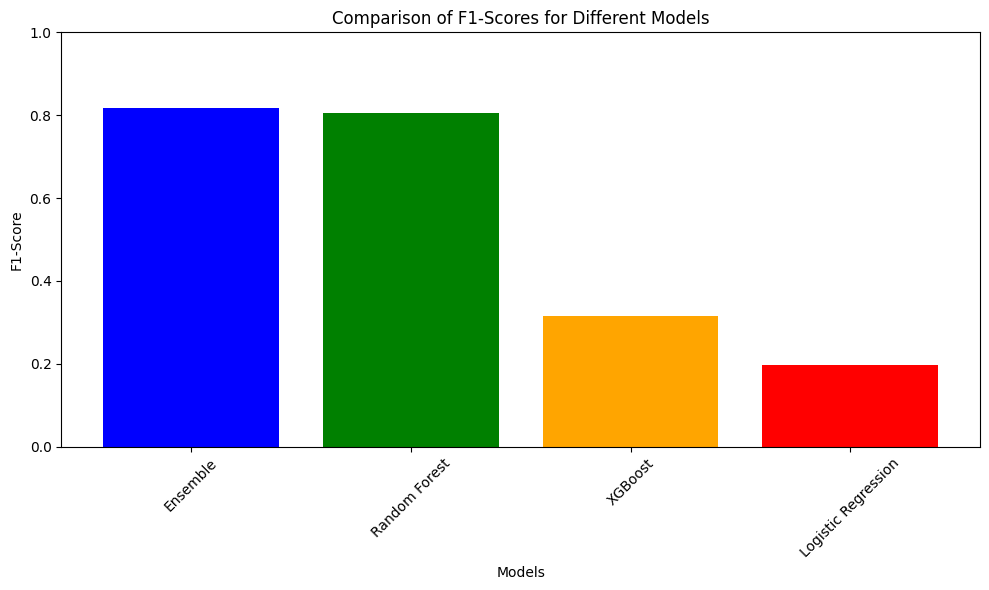

In [ ]:
# Create a dictionary to store the F1-Scores for each model
f1_scores = {
    'Logistic Regression': test_metrics_lr['F1-Score'],
    'Random Forest': test_metrics_rf['F1-Score'],
    'XGBoost': test_metrics_xgb['F1-Score'],
    'Ensemble': test_metrics_meta['F1-Score']
}

# Sort the models based on their F1-Scores in descending order
sorted_models = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)

# Extract sorted model names and F1-Scores
model_names = [model[0] for model in sorted_models]
f1_scores_values = [model[1] for model in sorted_models]

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_names, f1_scores_values, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Models')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores for Different Models')
plt.ylim(0, 1)  # Set the y-axis limits
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

**Observation**:

*   The Ensemble model is performing best even for the test datset.
*   The Random Forest model is the best when compared to individual model performance on the test dataset.

### **Best model(Ensemble model) feature importance analysis**

Feature: Time, Importance: 0.8502435684204102
Feature: V1, Importance: 0.07677038013935089
Feature: V3, Importance: 0.07298607379198074


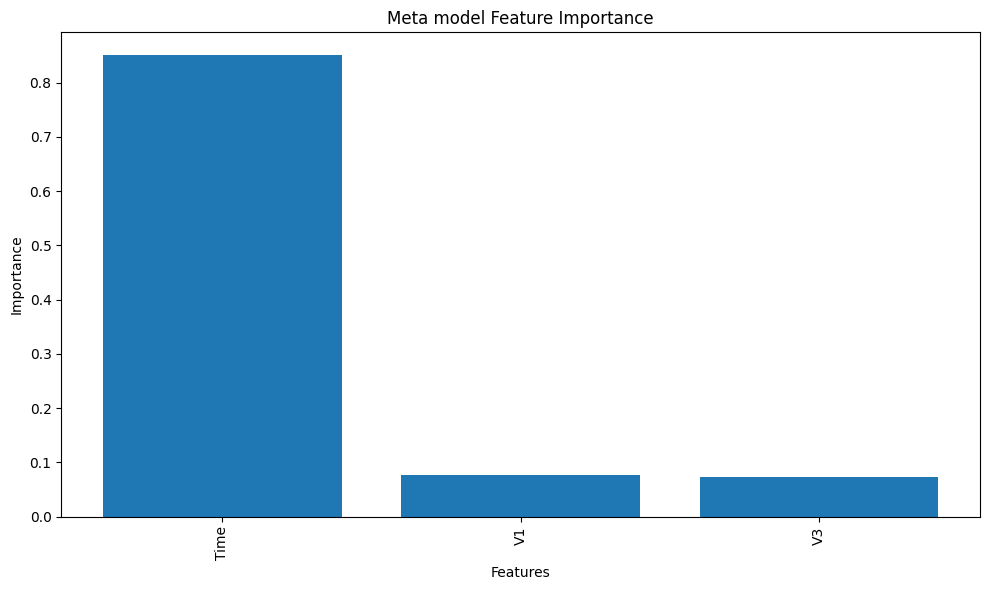

In [ ]:
# Get feature importances
feature_importances = meta_model.feature_importances_

# Get the names of your features
feature_names = list(X.columns)

# Create a dictionary of feature importance with feature names
feature_importance_dict = {feature: importance for feature, importance in zip(feature_names, feature_importances)}

# Sort the dictionary by feature importance in descending order
sorted_feature_importance = dict(sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True))

# Print the feature importance
for feature, importance in sorted_feature_importance.items():
    print(f"Feature: {feature}, Importance: {importance}")

# Plotting the feature importances
plt.figure(figsize=(10, 6))
plt.bar(sorted_feature_importance.keys(), sorted_feature_importance.values())
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Meta model Feature Importance')
plt.tight_layout()
plt.show()

**Observation**:


*   "Time" is the most influential feature with an importance of 0.85.
*   "V1" and "V3" are the next importance feature influencing the Ensemble model performance with an importance of around 0.7.

